# Official Clean Document for Randomizing the Last Two or Three Slow-Roll Parameters

In this document, I will be prepping paper ready images that I can include in my dissertation. This first set below will essentially run through of plots where I am varying the last three parameters. I do this for: $\lambda_4$/NEQs=7 and $\lambda_5$/NEQs=8.Be sure that those are the ones in the higgs_potential_tests folder that you have most recently run otherwise you'll need to adjust the folders these are pulling from.

As usual, we first run the imports:

In [123]:
import numpy as np
import random
from scipy.integrate import solve_ivp
import pygsl.rng #random num generator
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from matplotlib.ticker import ScalarFormatter


import sys
import os
import glob


#Should modify the Python import path at runtime
sys.path.append('/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/InflationModels')


from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import re

from scipy.interpolate import UnivariateSpline, splrep, splev, CubicSpline, interp1d, PchipInterpolator, InterpolatedUnivariateSpline
import numdifftools as nd
from scipy.integrate import cumulative_trapezoid, solve_ivp, odeint


from pathlib import Path



## Reusable functions:

In [124]:
SCAN_INFO = {
    5: ("lam2",  r"\lambda_2"),
    6: ("lam3",  r"\lambda_3"),
    7: ("lam4",  r"\lambda_4"),
    8: ("lam5",  r"\lambda_5"),
    9: ("lam6",  r"\lambda_6"),
    10: ("lam7", r"\lambda_7"),
    11: ("lam8", r"\lambda_8"),
    12: ("lam9", r"\lambda_9"),
    13: ("lam10", r"\lambda_{10}"),
}

colors = {
    5: "pink",
    6: "turquoise",
    7: "plum",
    8: "mediumslateblue",
    9: "blue",
}

def load_path_data(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}",
    )
    file_path = os.path.join(
        folder,
        f"path_neqs{NEQS}_{param_name}_{val_str}.dat",
    )
    return pd.read_csv(file_path, sep=r"\s+", header=None).values

def folder_for(NEQS, param_name, value):
    val_str = f"{value:.10e}"
    return os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

def load_specs(NEQS, param_name, value):
    folder = folder_for(NEQS, param_name, value)

    s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
    t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

    k_s = s[:, 0]
    Ps = np.abs(s[:, 1])

    k_t = t[:, 0]
    Pt = np.abs(t[:, 1])

    return k_s, Ps, k_t, Pt


    
def prepare_increasing(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    return x[order], y[order]

def normalize_curve_at_Nref(N, Y, N_ref=60.0, ref_floor=1e-20):
    N_use, Y_use = prepare_increasing(N, Y)

    if not (N_use.min() <= N_ref <= N_use.max()):
        raise ValueError(
            f"N_ref={N_ref} outside range [{N_use.min()}, {N_use.max()}]"
        )

    Y_ref = np.interp(N_ref, N_use, Y_use)

    if np.abs(Y_ref) < ref_floor:
        raise ValueError(f"Reference too small: {Y_ref:.3e}")

    return N_use, Y_use / Y_ref, Y_ref

def normalize_at_ref(k, P):
        k, P = prepare_increasing(k, P)
        P_ref = np.interp(k_ref, k, P)
        return k, P / P_ref, P_ref


def fractional_difference_on_overlap(x, y, x_ref, y_ref, frac_floor=1e-30):
    x, y = prepare_increasing(x, y)
    x_ref, y_ref = prepare_increasing(x_ref, y_ref)

    xmin = max(np.min(x), np.min(x_ref))
    xmax = min(np.max(x), np.max(x_ref))

    mask = (x >= xmin) & (x <= xmax)

    x_use = x[mask]
    y_use = y[mask]

    y_ref_interp = np.interp(x_use, x_ref, y_ref)

    frac = (y_use - y_ref_interp) / np.where(
        np.abs(y_ref_interp) > frac_floor,
        y_ref_interp,
        np.nan,
    )

    return x_use, frac


def get_base_dir(NEQS, param_name, base_value, base_path_root):
    val_str = f"{base_value:.10e}"
    folder = os.path.join(
        base_path_root,
        f"neqs{NEQS}",
        f"{param_name}_{val_str}"
    )

    if not os.path.exists(folder):
        raise FileNotFoundError(f"Missing base folder: {folder}")

    return folder



def get_param_values_from_dirs(NEQS, param_name, base_path_root, show_summary=True):
    base_path = f"{base_path_root}/neqs{NEQS}"
    pattern = os.path.join(base_path, f"{param_name}_*")
    dirs = glob.glob(pattern)

    values = []

    for d in dirs:
        try:
            base = os.path.basename(d)
            val_str = base.replace(f"{param_name}_", "")
            val = float(val_str)
            label = rf"${param_name} = {val:.1e}$"
            values.append((val, label))
        except Exception as e:
            print(f"Skipping {d}: {e}")

    values.sort(key=lambda x: x[0])

    if show_summary:
        print(f"\n{'='*60}")
        print(f"Summary for NEQS={NEQS}, parameter={param_name}")
        print(f"{'='*60}")
        print(f"Total models found: {len(values)}")
        if len(values) > 0:
            print(f"Parameter range: {values[0][0]:.3e} to {values[-1][0]:.3e}")
        else:
            print("Parameter range: none found")
        print(f"{'='*60}\n")

    return values

Let's call our base models we are interested in looking at here:

In [125]:
LAM_BASE = {
    7: ("lam4",  6.87065e-8),
    8: ("lam5", -8.92461e-9),
#     9: ("lam6", 6.1e-10), #we can test 9 later if we really want to 
}


base_path_root = "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests"


base_dirs = {}

for NEQS, (param_name, base_val) in LAM_BASE.items():
    folder = get_base_dir(NEQS, param_name, base_val, base_path_root)
    base_dirs[NEQS] = {
        "param_name": param_name,
        "value": base_val,
        "folder": folder
    }

    print(f"NEQS={NEQS}: {folder}")

NEQS=7: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs7/lam4_6.8706500000e-08
NEQS=8: /Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/neqs8/lam5_-8.9246100000e-09


I am gonna define the param_values_spread that I am interested in looking at:

In [126]:
lam5_values = get_param_values_from_dirs(8, "lam5", base_path_root)
lam4_values = get_param_values_from_dirs(7, "lam4", base_path_root)



Summary for NEQS=8, parameter=lam5
Total models found: 20
Parameter range: -4.368e-05 to 2.055e-05


Summary for NEQS=7, parameter=lam4
Total models found: 20
Parameter range: -1.457e-04 to 4.622e-04



# BEFORE APPLYING AN N-SHIFT

We run a set of models within the Kinney priors. We can examine what scalar and tensor power spectra look like before accounting for the relative N shift.


## Plot Spectra Variation

In [127]:
def plot_filtered_spectra_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.955,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=None,
    k_max_scalar=10.0,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    
    
    plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

    "axes.labelsize": 22,
    "axes.titlesize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 15,
    "figure.titlesize": 24,

    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    })

        
        
    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_observables(value):
        arr = np.loadtxt(
            os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat")
        )
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_specs(value):
        folder = folder_for(value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        return k_s, Ps, k_t, Pt

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)

        dx = np.diff(x)

        if np.all(dx >= 0):
            return x, y
        elif np.all(dx <= 0):
            return x[::-1], y[::-1]
        else:
            order = np.argsort(x)
            return x[order], y[order]

    def normalize_at_ref(x, y, x_ref):
        x, y = prepare_increasing(x, y)

        if not (np.min(x) <= x_ref <= np.max(x)):
            raise ValueError(
                f"k_ref={x_ref} outside range [{np.min(x):.4e}, {np.max(x):.4e}]"
            )

        y_ref = np.interp(x_ref, x, y)

        if np.abs(y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at k_ref={x_ref}")

        return x, y / y_ref

    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool)

        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

    def frac_on_base_grid(
        x_base,
        y_base,
        x_cmp,
        y_cmp,
        xmin=None,
        xmax=None,
    ):
        x_base, y_base = prepare_increasing(x_base, y_base)
        x_cmp, y_cmp = prepare_increasing(x_cmp, y_cmp)

        xlo = max(np.min(x_base), np.min(x_cmp))
        xhi = min(np.max(x_base), np.max(x_cmp))

        if xmin is not None:
            xlo = max(xlo, xmin)

        if xmax is not None:
            xhi = min(xhi, xmax)

        mask = (x_base >= xlo) & (x_base <= xhi)

        x_use = x_base[mask]
        y_base_use = y_base[mask]

        if len(x_use) == 0:
            raise ValueError(
                f"No overlapping k-values in requested range [{xlo:.4e}, {xhi:.4e}]"
            )

        y_cmp_interp = np.interp(x_use, x_cmp, y_cmp)

        frac = (y_cmp_interp - y_base_use) / y_base_use

        return x_use, frac

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)

    k_s_base_raw, Ps_base_raw, k_t_base_raw, Pt_base_raw = load_specs(baseX)

    k_s_base, Ps_base_norm = normalize_at_ref(k_s_base_raw, Ps_base_raw, k_ref)
    k_t_base, Pt_base_norm = normalize_at_ref(k_t_base_raw, Pt_base_raw, k_ref)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(lamX)

            k_s, Ps_norm = normalize_at_ref(k_s_raw, Ps_raw, k_ref)
            k_t, Pt_norm = normalize_at_ref(k_t_raw, Pt_raw, k_ref)

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                xmin=k_min_scalar,
                xmax=k_max_scalar,
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                xmin=None,
                xmax=None,
            )

            mean_dPs_pct = 100.0 * np.nanmean(frac_ps)
            max_dPs_pct = 100.0 * np.nanmax(np.abs(frac_ps))
            mean_dPt_pct = 100.0 * np.nanmean(frac_pt)
            max_dPt_pct = 100.0 * np.nanmax(np.abs(frac_pt))

            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "mean_dPs_pct": mean_dPs_pct,
                "max_dPs_pct": max_dPs_pct,
                "mean_dPt_pct": mean_dPt_pct,
                "max_dPt_pct": max_dPt_pct,
                "kept_by_ns_cut": keep,
            }

            rows.append(row)

            if keep:
                kept_models.append({
                    **row,
                    "k_s": k_s,
                    "Ps_norm": Ps_norm,
                    "k_t": k_t,
                    "Pt_norm": Pt_norm,
                    "k_ps_err": k_ps_err,
                    "frac_ps": frac_ps,
                    "k_pt_err": k_pt_err,
                    "frac_pt": frac_pt,
                })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")
    kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== All models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_df)}")

    if not kept_df.empty:
        print("\n=== Filtered models by ns cut ===")
        print(
            kept_df[[
                "lamX",
                "ns",
                "delta_ns_from_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

        print("\n=== Error shrink check in percentages ===")
        print("All models:")
        print(
            stats_df[[
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]]
            .agg(["mean", "max"])
            .to_string()
        )

        print("\nFiltered models:")
        print(
            kept_df[[
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]]
            .agg(["mean", "max"])
            .to_string()
        )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(18, 12),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            mask_ps_plot = scalar_k_mask(m["k_s"])

            ax_ps.loglog(
                m["k_s"][mask_ps_plot],
                m["Ps_norm"][mask_ps_plot],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_pt.loglog(
                m["k_t"],
                m["Pt_norm"],
                color=color,
                lw=1.8,
                alpha=0.85,
            )

            ax_ps_err.semilogx(
                m["k_ps_err"],
                100.0 * m["frac_ps"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

            ax_pt_err.semilogx(
                m["k_pt_err"],
                100.0 * m["frac_pt"],
                color=color,
                lw=1.5,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    mask_base_s = scalar_k_mask(k_s_base)

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=0.8,
            alpha=0.6,
        )

    ax_ps.axvline(k_ref, color="black", ls=":", alpha=0.7)
    ax_pt.axvline(k_ref, color="black", ls=":", alpha=0.7)

    ax_ps.set_title(
        rf"Filtered normalized scalar spectra: $P_s/P_s({k_ref})$"
    )
    ax_pt.set_title(
        rf"Filtered normalized tensor spectra: $P_t/P_t({k_ref})$"
    )
    ax_ps_err.set_title(r"Filtered scalar fractional error")
    ax_pt_err.set_title(r"Filtered tensor fractional error")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(r"$P_s/P_s(k_{\rm ref})$")
    ax_pt.set_ylabel(r"$P_t/P_t(k_{\rm ref})$")
    ax_ps_err.set_ylabel(r"$100\times\Delta P_s/P_{s,\rm base}$")
    ax_pt_err.set_ylabel(r"$100\times\Delta P_t/P_{t,\rm base}$")

    xmin_scalar = (
        k_min_scalar
        if k_min_scalar is not None
        else np.min(k_s_base[mask_base_s])
    )

    xmax_scalar = (
        k_max_scalar
        if k_max_scalar is not None
        else np.max(k_s_base[mask_base_s])
    )

    ax_ps.set_xlim(xmin_scalar, xmax_scalar)
    ax_ps_err.set_xlim(xmin_scalar, xmax_scalar)

    for ax in axes.ravel():
        ax.grid(True, alpha=0.25)
        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=15)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=24,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_{scan_name}_filtered_ns_"
            f"{ns_min}_{ns_max}_kmin{k_min_scalar}_kmax{k_max_scalar}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return stats_df, kept_df

This gets run like so:


=== All models summary ===
Total loaded: 20
Base ns: 0.967201
Models in ns window [0.967, 0.971]: 7

=== Filtered models by ns cut ===
        lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
4.621929e-04 0.967044           -0.000158      3.101729     4.920135      1.323520     5.131844
6.870650e-08 0.967201            0.000000      0.000000     0.000000      0.000000     0.000000
2.390691e-04 0.967313            0.000112      2.866515     4.504444      1.297453     5.047788
5.241213e-05 0.967465            0.000263      0.652509     1.048407      1.366721     5.437288
2.536168e-04 0.968003            0.000802      2.947163     4.575161      1.288787     5.013259
5.404828e-05 0.968845            0.001644      0.330760     0.631103      1.367454     5.441052
6.945215e-05 0.969825            0.002624      1.854621     2.878925      1.176915     4.694042

=== Error shrink check in percentages ===
All models:
      mean_dPs_pct  max_dPs_pct  mean_dPt

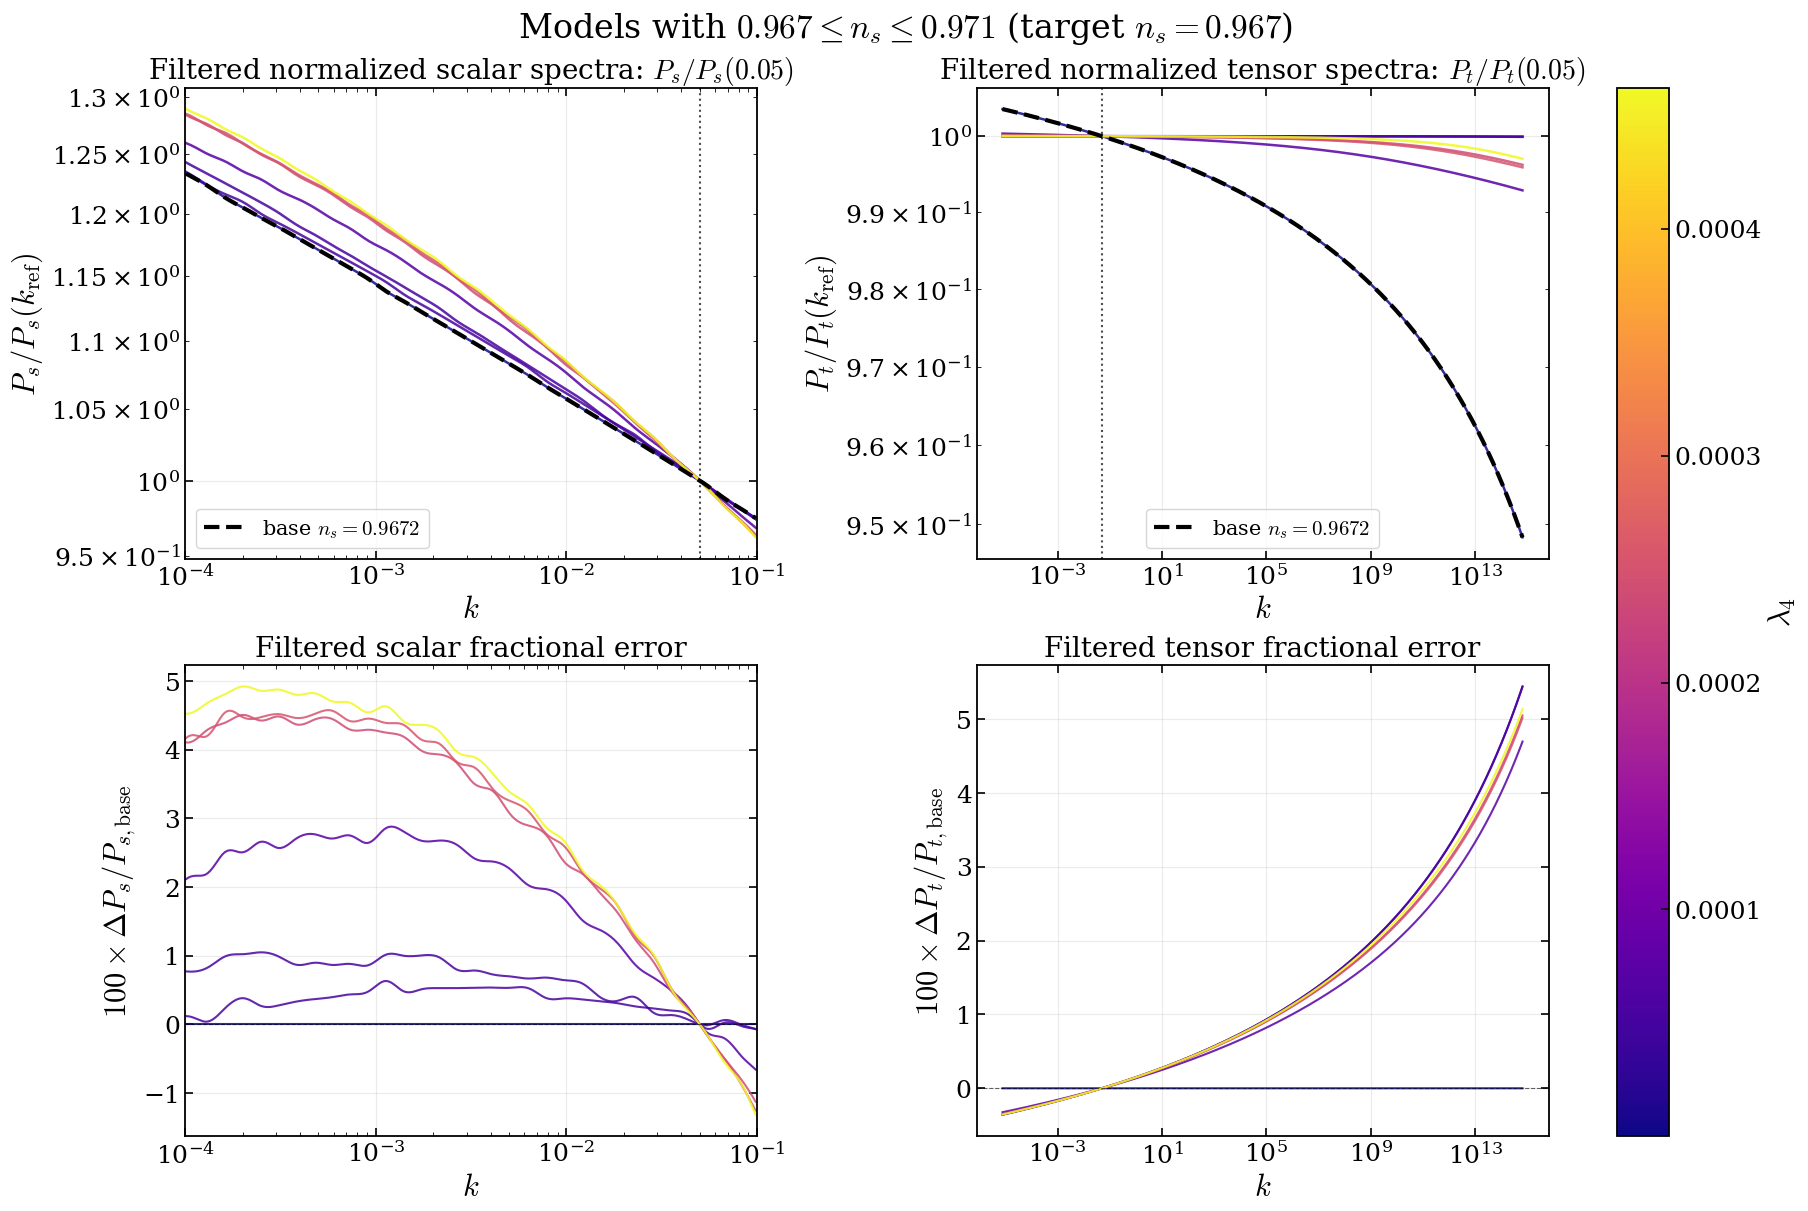


=== All models summary ===
Total loaded: 20
Base ns: 0.969485
Models in ns window [0.96, 0.971]: 20

=== Filtered models by ns cut ===
         lamX       ns  delta_ns_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
 2.055446e-05 0.960474           -0.009012      5.657910    10.437436      1.029580     3.735363
-2.159077e-05 0.961350           -0.008136      3.253971     6.756279      0.528412     3.046322
-2.570681e-05 0.962248           -0.007237      3.195280     6.352609      0.995112     3.646317
-4.368160e-05 0.963749           -0.005737     -8.518946    12.175035      0.929433     3.767642
-1.702759e-05 0.963908           -0.005578      0.816558     2.400135      0.439198     2.781305
-2.732926e-05 0.965133           -0.004353      0.107328     1.081662      0.556863     3.032561
-4.299231e-05 0.965168           -0.004317     -2.254840     3.922525      0.577833     3.066514
-3.670782e-05 0.965415           -0.004070     -0.502837     1.170206      0.728678     

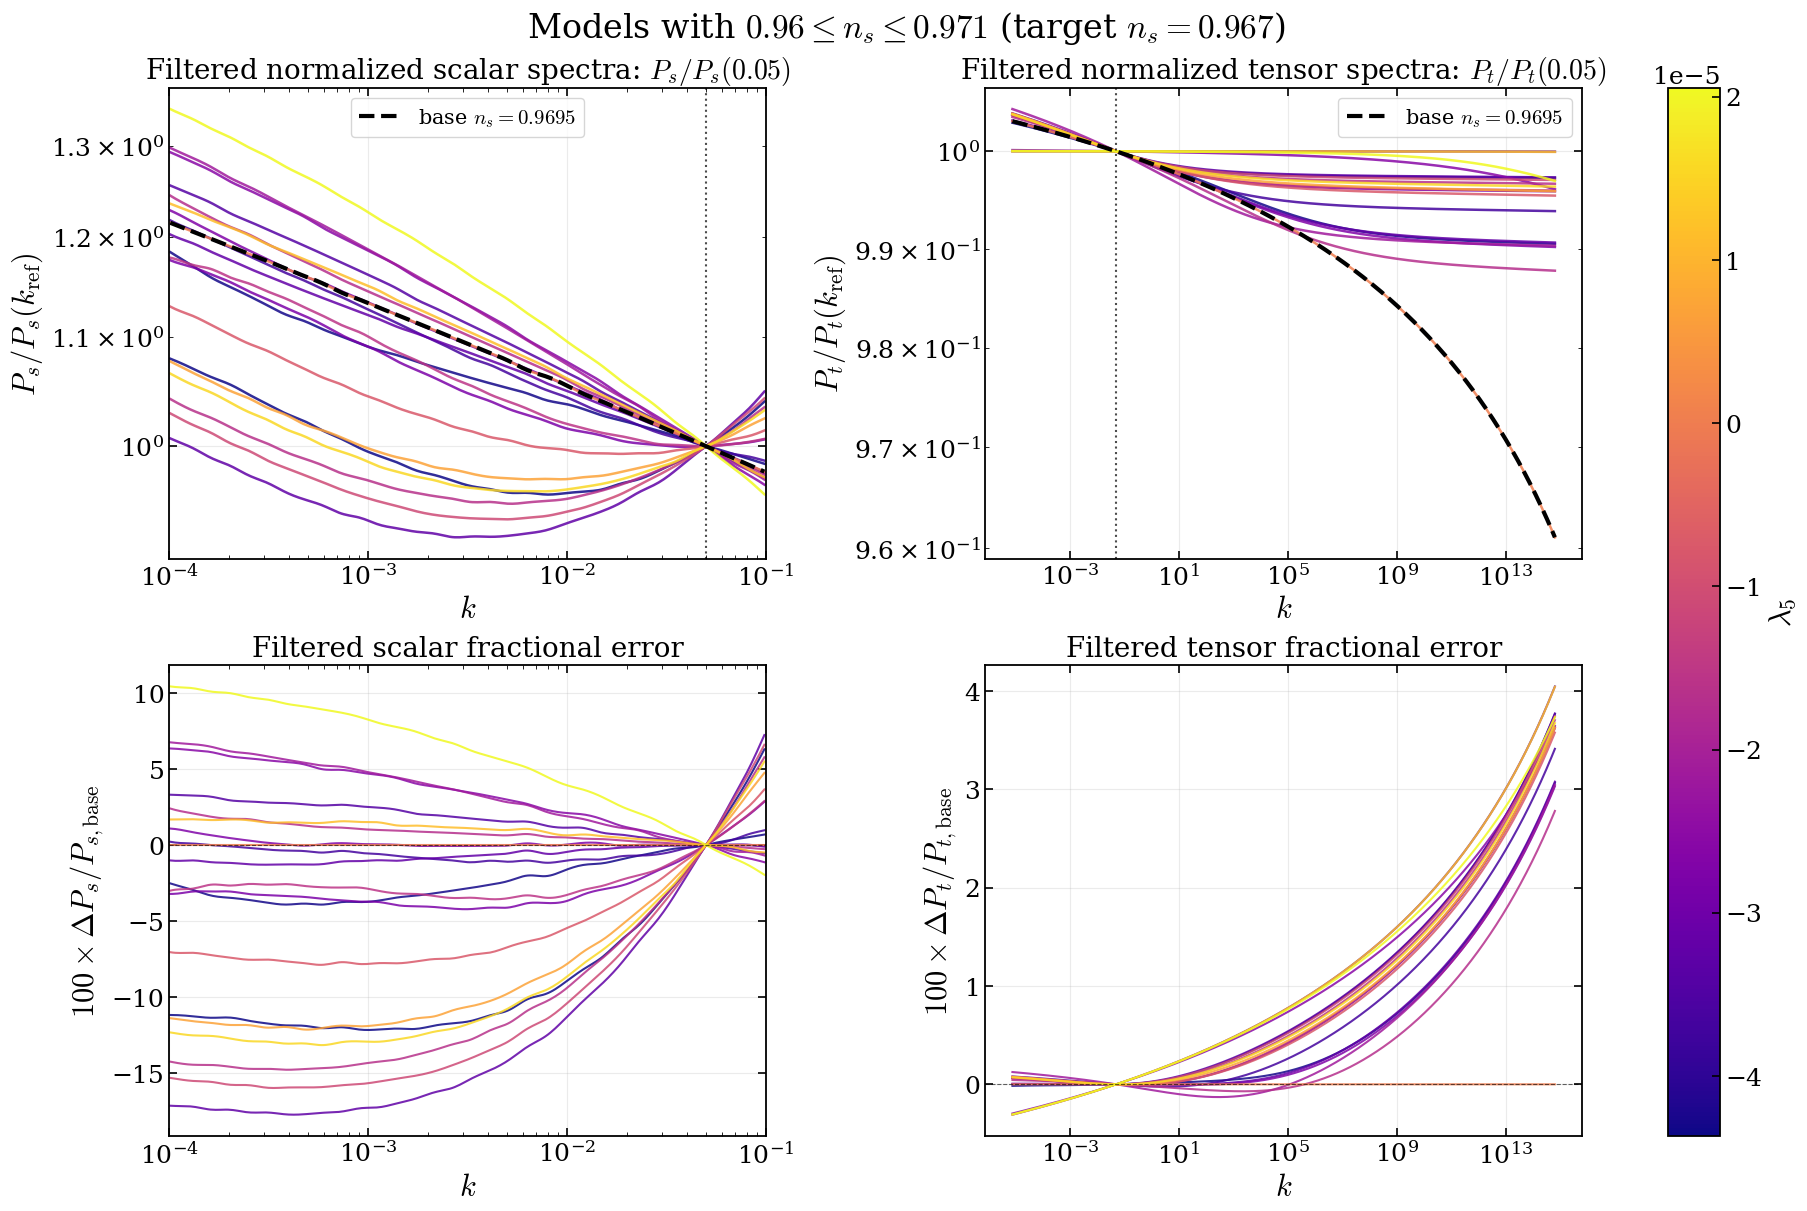

In [128]:
stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=7,
    lamX_values=lam4_values,
    baseX= 6.87065e-08,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.967,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    save_name="neqs7_lam4_filtered_ns_spectra.png"
)


stats_df, kept_df = plot_filtered_spectra_by_ns(
    NEQS=8,
    lamX_values=lam5_values,
    baseX= -8.92461e-9,
    base_path_root="/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests",
    ns_min=0.96,
    ns_max=0.971,
    ns_target=0.967,
    k_ref=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    save_name="neqs8_lam5_filtered_ns_spectra.png"
)


#If we do neqs9 that is base at 6.1e-10


## Plot Background Variables (Before N-shift)
To examine what those background variables $H(N)$,$V(N)$, $H(\phi)$,$V(\phi)$ look like we can use the following:

In [129]:
# def plot_filtered_background_by_ns(
#     NEQS,
#     lamX_values,
#     baseX,
#     base_path_root,
#     ns_min=0.96,
#     ns_max=0.971,
#     ns_target=0.967,
#     N_ref=60.0,
#     N_window=None,
#     cmap_name="plasma",
#     frac_ylim=None,
#     save_name=None,
#     show=True,
# ):
#     scan_name, scan_symbol = SCAN_INFO[NEQS]

#     def sanitize_lam_values(vals):
#         return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

#     def folder_for(value):
#         val_str = f"{value:.10e}"
#         return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

#     def load_observables(value):
#         arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
#         arr = np.atleast_1d(arr)
#         return arr[0], arr[1], arr[2]

#     def load_path(value):
#         val_str = f"{value:.10e}"
#         f = os.path.join(folder_for(value), f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")
#         return pd.read_csv(f, sep=r"\s+", header=None).values

#     def prepare_increasing(x, y):
#         x = np.asarray(x)
#         y = np.asarray(y)
#         order = np.argsort(x)
#         return x[order], y[order]

#     def normalize_at_ref(N, Y, N_ref):
#         N_use, Y_use = prepare_increasing(N, Y)

#         if not (np.min(N_use) <= N_ref <= np.max(N_use)):
#             raise ValueError(
#                 f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
#             )

#         Y_ref = np.interp(N_ref, N_use, Y_use)

#         if np.abs(Y_ref) < 1e-30:
#             raise ValueError(f"Reference value too small at N_ref={N_ref}")

#         return N_use, Y_use / Y_ref, Y_ref

#     def apply_N_window(N, Y):
#         if N_window is None:
#             return N, Y

#         Nmin, Nmax = N_window
#         mask = (N >= Nmin) & (N <= Nmax)
#         return N[mask], Y[mask]

#     def fractional_error_on_base_grid(N_base, Y_base, N_model, Y_model):
#         N_base, Y_base = prepare_increasing(N_base, Y_base)
#         N_model, Y_model = prepare_increasing(N_model, Y_model)

#         Nmin = max(np.min(N_base), np.min(N_model))
#         Nmax = min(np.max(N_base), np.max(N_model))

#         if N_window is not None:
#             Nmin = max(Nmin, N_window[0])
#             Nmax = min(Nmax, N_window[1])

#         mask = (N_base >= Nmin) & (N_base <= Nmax)

#         N_use = N_base[mask]
#         Y_base_use = Y_base[mask]

#         if len(N_use) == 0:
#             raise ValueError("No overlapping N range between model and base.")

#         Y_model_interp = np.interp(N_use, N_model, Y_model)

#         frac = (Y_model_interp - Y_base_use) / Y_base_use

#         return N_use, frac

#     plt.rcParams.update({
#         "text.usetex": False,
#         "mathtext.fontset": "cm",
#         "font.family": "serif",
#         "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

#         "axes.labelsize": 20,
#         "axes.titlesize": 18,
#         "xtick.labelsize": 16,
#         "ytick.labelsize": 16,
#         "legend.fontsize": 14,
#         "figure.titlesize": 22,

#         "axes.linewidth": 1.3,
#         "xtick.direction": "in",
#         "ytick.direction": "in",
#         "xtick.top": True,
#         "ytick.right": True,
#     })

#     lam_vals = sanitize_lam_values(lamX_values)

#     r_base, ns_base, alpha_base = load_observables(baseX)
#     base_data = load_path(baseX)

#     H_base = base_data[:, 1]
#     N_base = base_data[:, NEQS]
#     V_base = base_data[:, NEQS + 1]

#     N_base_H, H_base_norm, H_ref = normalize_at_ref(N_base, H_base, N_ref)
#     N_base_V, V_base_norm, V_ref = normalize_at_ref(N_base, V_base, N_ref)

#     N_base_H_plot, H_base_plot = apply_N_window(N_base_H, H_base_norm)
#     N_base_V_plot, V_base_plot = apply_N_window(N_base_V, V_base_norm)

#     rows = []
#     kept_models = []

#     for lamX in lam_vals:
#         try:
#             r, ns, alpha_s = load_observables(lamX)
#             keep = ns_min <= ns <= ns_max

#             row = {
#                 "lamX": lamX,
#                 "r": r,
#                 "ns": ns,
#                 "alpha_s": alpha_s,
#                 "delta_ns_from_base": ns - ns_base,
#                 "delta_ns_from_target": ns - ns_target,
#                 "kept_by_ns_cut": keep,
#             }
#             rows.append(row)

#             if not keep:
#                 continue

#             data = load_path(lamX)

#             H = data[:, 1]
#             N = data[:, NEQS]
#             V = data[:, NEQS + 1]

#             N_H, H_norm, _ = normalize_at_ref(N, H, N_ref)
#             N_V, V_norm, _ = normalize_at_ref(N, V, N_ref)

#             N_H_plot, H_plot = apply_N_window(N_H, H_norm)
#             N_V_plot, V_plot = apply_N_window(N_V, V_norm)

#             N_frac_H, frac_H = fractional_error_on_base_grid(
#                 N_base_H,
#                 H_base_norm,
#                 N_H,
#                 H_norm,
#             )

#             N_frac_V, frac_V = fractional_error_on_base_grid(
#                 N_base_V,
#                 V_base_norm,
#                 N_V,
#                 V_norm,
#             )

#             kept_models.append({
#                 **row,
#                 "N_H": N_H_plot,
#                 "H_N": H_plot,
#                 "N_V": N_V_plot,
#                 "V_N": V_plot,
#                 "N_frac_H": N_frac_H,
#                 "frac_H": frac_H,
#                 "N_frac_V": N_frac_V,
#                 "frac_V": frac_V,
#                 "mean_dH_pct": 100.0 * np.nanmean(frac_H),
#                 "max_dH_pct": 100.0 * np.nanmax(np.abs(frac_H)),
#                 "mean_dV_pct": 100.0 * np.nanmean(frac_V),
#                 "max_dV_pct": 100.0 * np.nanmax(np.abs(frac_V)),
#             })

#         except FileNotFoundError:
#             print(f"Missing files for {scan_name}={lamX:.5e}")
#         except ValueError as e:
#             print(f"Skipping {scan_name}={lamX:.5e}: {e}")

#     stats_df = pd.DataFrame(rows).sort_values("ns")

#     if len(kept_models) > 0:
#         kept_df = pd.DataFrame(kept_models).drop(
#             columns=["N_H", "H_N", "N_V", "V_N", "N_frac_H", "frac_H", "N_frac_V", "frac_V"]
#         )
#     else:
#         kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

#     print("\n=== Background models summary ===")
#     print(f"Total loaded: {len(stats_df)}")
#     print(f"Base ns: {ns_base:.6f}")
#     print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_models)}")

#     if len(kept_models) > 0:
#         print("\n=== Background fractional errors in percent ===")
#         print(
#             kept_df[[
#                 "lamX",
#                 "ns",
#                 "mean_dH_pct",
#                 "max_dH_pct",
#                 "mean_dV_pct",
#                 "max_dV_pct",
#             ]].to_string(index=False)
#         )


#     fig, axes = plt.subplots(
#             2,
#             2,
#             figsize=(18, 12),
#             constrained_layout=True,
#         )
    
#     ax_HN, ax_VN = axes[0]
#     ax_Herr, ax_Verr = axes[1]

#     if len(kept_models) > 0:
#         lam_kept = np.array([m["lamX"] for m in kept_models])
#         cmap = plt.get_cmap(cmap_name)
#         norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

#         for m in kept_models:
#             color = cmap(norm(m["lamX"]))

#             ax_HN.plot(m["N_H"], m["H_N"], color=color, lw=1.8, alpha=0.85)
#             ax_VN.plot(m["N_V"], m["V_N"], color=color, lw=1.8, alpha=0.85)

#             ax_Herr.plot(
#                 m["N_frac_H"],
#                 100.0 * m["frac_H"],
#                 color=color,
#                 lw=1.6,
#                 alpha=0.85,
#             )

#             ax_Verr.plot(
#                 m["N_frac_V"],
#                 100.0 * m["frac_V"],
#                 color=color,
#                 lw=1.6,
#                 alpha=0.85,
#             )

#         sm = cm.ScalarMappable(cmap=cmap, norm=norm)
#         fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

#     ax_HN.plot(
#         N_base_H_plot,
#         H_base_plot,
#         color="black",
#         lw=3,
#         ls="--",
#         label=rf"base $n_s={ns_base:.4f}$",
#     )

#     ax_VN.plot(
#         N_base_V_plot,
#         V_base_plot,
#         color="black",
#         lw=3,
#         ls="--",
#         label=rf"base $n_s={ns_base:.4f}$",
#     )

#     ax_Herr.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)
#     ax_Verr.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)

#     ax_HN.set_title(rf"Filtered normalized Hubble evolution: $H/H(N={N_ref})$")
#     ax_VN.set_title(rf"Filtered normalized potential evolution: $V/V(N={N_ref})$")
#     ax_Herr.set_title(r"Fractional difference in normalized Hubble evolution")
#     ax_Verr.set_title(r"Fractional difference in normalized potential evolution")

#     ax_HN.set_xlabel(r"$N$")
#     ax_VN.set_xlabel(r"$N$")
#     ax_Herr.set_xlabel(r"$N$")
#     ax_Verr.set_xlabel(r"$N$")

#     ax_HN.set_ylabel(rf"$H/H(N={N_ref})$")
#     ax_VN.set_ylabel(rf"$V/V(N={N_ref})$")
#     ax_Herr.set_ylabel(r"$100\times\Delta H/H_{\rm base}$")
#     ax_Verr.set_ylabel(r"$100\times\Delta V/V_{\rm base}$")

#     if frac_ylim is not None:
#         ax_Herr.set_ylim(frac_ylim)
#         ax_Verr.set_ylim(frac_ylim)

#     for ax in axes.ravel():
#         ax.invert_xaxis()
#         ax.grid(True, alpha=0.25)
#         handles, labels = ax.get_legend_handles_labels()
#         if len(handles) > 0:
#             ax.legend(fontsize=12)

#     fig.suptitle(
#         rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
#         rf"(target $n_s={ns_target}$)",
#         fontsize=22,
#     )

#     if save_name is None:
#         save_name = f"neqs{NEQS}_{scan_name}_filtered_ns_background_errors.png"

#     plt.savefig(save_name, dpi=300, bbox_inches="tight")

#     if show:
#         plt.show()
#     else:
#         plt.close(fig)

#     return kept_df

In [204]:
def plot_filtered_background_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.96,
    ns_max=0.971,
    ns_target=0.967,
    N_ref=60.0,
    N_window=None,
    cmap_name="plasma",
    frac_ylim=None,
    eps_frac_ylim=None,
    save_name=None,
    show=True,
):
    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_observables(value):
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_path(value):
        val_str = f"{value:.10e}"
        f = os.path.join(folder_for(value), f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")
        return pd.read_csv(f, sep=r"\s+", header=None).values

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_at_ref(N, Y, N_ref):
        N_use, Y_use = prepare_increasing(N, Y)

        if not (np.min(N_use) <= N_ref <= np.max(N_use)):
            raise ValueError(
                f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
            )

        Y_ref = np.interp(N_ref, N_use, Y_use)

        if np.abs(Y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at N_ref={N_ref}")

        return N_use, Y_use / Y_ref, Y_ref

    def apply_N_window(N, Y):
        if N_window is None:
            return N, Y

        Nmin, Nmax = N_window
        mask = (N >= Nmin) & (N <= Nmax)
        return N[mask], Y[mask]

    def fractional_error_on_base_grid(N_base, Y_base, N_model, Y_model):
        N_base, Y_base = prepare_increasing(N_base, Y_base)
        N_model, Y_model = prepare_increasing(N_model, Y_model)

        Nmin = max(np.min(N_base), np.min(N_model))
        Nmax = min(np.max(N_base), np.max(N_model))

        if N_window is not None:
            Nmin = max(Nmin, N_window[0])
            Nmax = min(Nmax, N_window[1])

        mask = (N_base >= Nmin) & (N_base <= Nmax)

        N_use = N_base[mask]
        Y_base_use = Y_base[mask]

        if len(N_use) == 0:
            raise ValueError("No overlapping N range between model and base.")

        Y_model_interp = np.interp(N_use, N_model, Y_model)
        frac = (Y_model_interp - Y_base_use) / Y_base_use

        return N_use, frac

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "figure.titlesize": 22,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)
    base_data = load_path(baseX)

    H_base = base_data[:, 1]
    eps_base = base_data[:, 2]
    N_base = base_data[:, NEQS]
    V_base = base_data[:, NEQS + 1]

    N_base_H, H_base_norm, H_ref = normalize_at_ref(N_base, H_base, N_ref)
    N_base_eps, eps_base_norm, eps_ref = normalize_at_ref(N_base, eps_base, N_ref)
    N_base_V, V_base_norm, V_ref = normalize_at_ref(N_base, V_base, N_ref)

    N_base_H_plot, H_base_plot = apply_N_window(N_base_H, H_base_norm)
    N_base_eps_plot, eps_base_plot = apply_N_window(N_base_eps, eps_base_norm)
    N_base_V_plot, V_base_plot = apply_N_window(N_base_V, V_base_norm)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)
            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "kept_by_ns_cut": keep,
            }
            rows.append(row)

            if not keep:
                continue

            data = load_path(lamX)

            H = data[:, 1]
            eps = data[:, 2]
            N = data[:, NEQS]
            V = data[:, NEQS + 1]

            N_H, H_norm, _ = normalize_at_ref(N, H, N_ref)
            N_eps, eps_norm, _ = normalize_at_ref(N, eps, N_ref)
            N_V, V_norm, _ = normalize_at_ref(N, V, N_ref)

            N_H_plot, H_plot = apply_N_window(N_H, H_norm)
            N_eps_plot, eps_plot = apply_N_window(N_eps, eps_norm)
            N_V_plot, V_plot = apply_N_window(N_V, V_norm)

            N_frac_H, frac_H = fractional_error_on_base_grid(
                N_base_H, H_base_norm, N_H, H_norm
            )

            N_frac_eps, frac_eps = fractional_error_on_base_grid(
                N_base_eps, eps_base_norm, N_eps, eps_norm
            )

            N_frac_V, frac_V = fractional_error_on_base_grid(
                N_base_V, V_base_norm, N_V, V_norm
            )

            kept_models.append({
                **row,

                "N_H": N_H_plot,
                "H_N": H_plot,
                "N_eps": N_eps_plot,
                "eps_N": eps_plot,
                "N_V": N_V_plot,
                "V_N": V_plot,

                "N_frac_H": N_frac_H,
                "frac_H": frac_H,
                "N_frac_eps": N_frac_eps,
                "frac_eps": frac_eps,
                "N_frac_V": N_frac_V,
                "frac_V": frac_V,

                "mean_dH_pct": 100.0 * np.nanmean(frac_H),
                "max_dH_pct": 100.0 * np.nanmax(np.abs(frac_H)),
                "mean_deps_pct": 100.0 * np.nanmean(frac_eps),
                "max_deps_pct": 100.0 * np.nanmax(np.abs(frac_eps)),
                "mean_dV_pct": 100.0 * np.nanmean(frac_V),
                "max_dV_pct": 100.0 * np.nanmax(np.abs(frac_V)),
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")

    if len(kept_models) > 0:
        kept_df = pd.DataFrame(kept_models).drop(
            columns=[
                "N_H", "H_N",
                "N_eps", "eps_N",
                "N_V", "V_N",
                "N_frac_H", "frac_H",
                "N_frac_eps", "frac_eps",
                "N_frac_V", "frac_V",
            ]
        )
    else:
        kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== Background models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_models)}")

    if len(kept_models) > 0:
        print("\n=== Background fractional errors in percent ===")
        print(
            kept_df[[
                "lamX",
                "ns",
                "mean_dH_pct",
                "max_dH_pct",
                "mean_deps_pct",
                "max_deps_pct",
                "mean_dV_pct",
                "max_dV_pct",
            ]].to_string(index=False)
        )

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(18, 16),
        constrained_layout=True,
    )

    ax_HN, ax_VN = axes[0]
    ax_Herr, ax_Verr = axes[1]
    ax_epsN, ax_epserr = axes[2]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            ax_HN.plot(m["N_H"], m["H_N"], color=color, lw=1.8, alpha=0.85)
            ax_VN.plot(m["N_V"], m["V_N"], color=color, lw=1.8, alpha=0.85)
            ax_epsN.plot(m["N_eps"], m["eps_N"], color=color, lw=1.8, alpha=0.85)

            ax_Herr.plot(
                m["N_frac_H"],
                100.0 * m["frac_H"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

            ax_Verr.plot(
                m["N_frac_V"],
                100.0 * m["frac_V"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

            ax_epserr.plot(
                m["N_frac_eps"],
                100.0 * m["frac_eps"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    ax_HN.plot(
        N_base_H_plot,
        H_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_VN.plot(
        N_base_V_plot,
        V_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_epsN.plot(
        N_base_eps_plot,
        eps_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    for ax in [ax_Herr, ax_Verr, ax_epserr]:
        ax.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)

    ax_HN.set_title(rf"Filtered normalized Hubble evolution: $H/H(N={N_ref})$")
    ax_VN.set_title(rf"Filtered normalized potential evolution: $V/V(N={N_ref})$")
    ax_epsN.set_title(rf"Filtered normalized slow-roll evolution: $\epsilon/\epsilon(N={N_ref})$")

    ax_Herr.set_title(r"Fractional difference in normalized Hubble evolution")
    ax_Verr.set_title(r"Fractional difference in normalized potential evolution")
    ax_epserr.set_title(r"Fractional difference in normalized $\epsilon(N)$")

    for ax in axes.ravel():
        ax.set_xlabel(r"$N$")
        ax.invert_xaxis()
        ax.grid(True, alpha=0.25)

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=12)

    ax_HN.set_ylabel(rf"$H/H(N={N_ref})$")
    ax_VN.set_ylabel(rf"$V/V(N={N_ref})$")
    ax_epsN.set_ylabel(rf"$\epsilon/\epsilon(N={N_ref})$")

    ax_Herr.set_ylabel(r"$100\times\Delta H/H_{\rm base}$")
    ax_Verr.set_ylabel(r"$100\times\Delta V/V_{\rm base}$")
    ax_epserr.set_ylabel(r"$100\times\Delta\epsilon/\epsilon_{\rm base}$")

    if frac_ylim is not None:
        ax_Herr.set_ylim(frac_ylim)
        ax_Verr.set_ylim(frac_ylim)

    if eps_frac_ylim is not None:
        ax_epserr.set_ylim(eps_frac_ylim)

    fig.suptitle(
        rf"Models with ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=22,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_filtered_ns_background_errors_with_epsilon.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return kept_df

The background variables get plotted like so:


=== Background models summary ===
Total loaded: 20
Base ns: 0.967201
Models in ns window [0.96, 0.971]: 20

=== Background fractional errors in percent ===
         lamX       ns  mean_dH_pct  max_dH_pct  mean_deps_pct  max_deps_pct  mean_dV_pct  max_dV_pct
-1.457135e-04 0.961134     0.882991    2.150469      74.464109    216.648857     1.793597    4.393260
 6.870650e-08 0.967201     0.000000    0.000000       0.000000      0.000000     0.000000    0.000000
 7.275650e-06 0.961281     0.883300    2.151453      67.357360    190.942728     1.794247    4.395339
 5.241213e-05 0.967465     0.882852    2.150214      45.039732    134.453340     1.793340    4.392742
 5.357388e-05 0.961140     0.883506    2.152092      68.774424    195.357886     1.794685    4.396655
 5.404828e-05 0.968845     0.883295    2.151480      44.434213    135.548514     1.794219    4.395331
 6.945215e-05 0.969825     0.764895    1.846901      43.822417     76.183955     1.551771    3.767985
 8.445728e-05 0.961164     

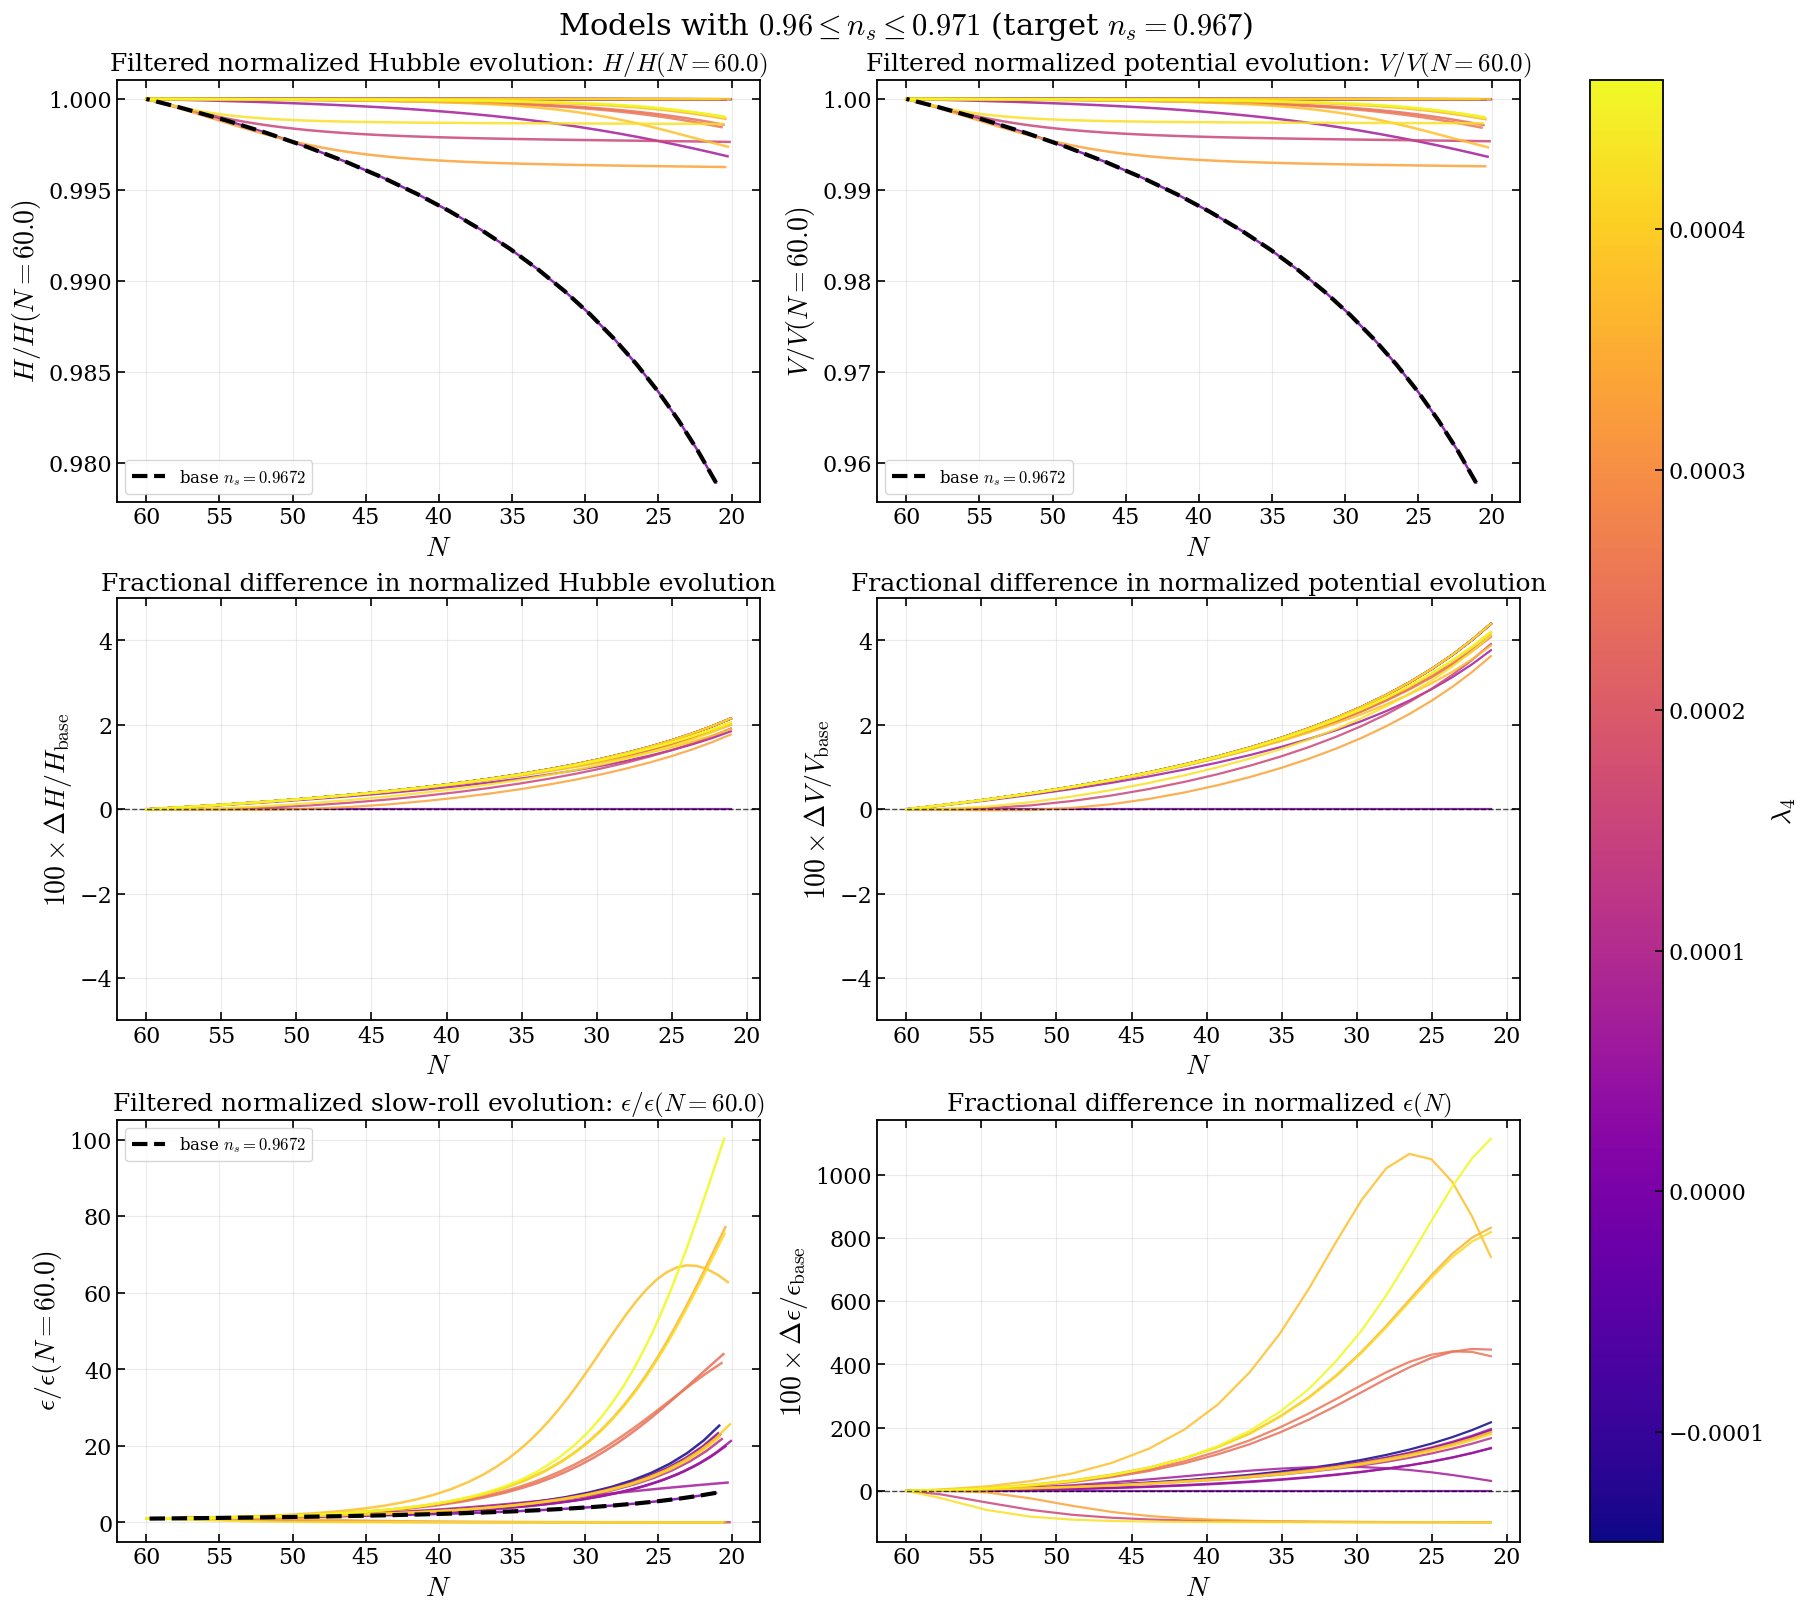


=== Background models summary ===
Total loaded: 20
Base ns: 0.969485
Models in ns window [0.96, 0.971]: 20

=== Background fractional errors in percent ===
         lamX       ns  mean_dH_pct  max_dH_pct  mean_deps_pct  max_deps_pct  mean_dV_pct  max_dV_pct
-4.368160e-05 0.963749     0.522039    1.448343     -79.357000     99.722924     1.065809    2.956590
-4.299231e-05 0.965168     0.338329    1.132197     -55.907917     98.164601     0.691944    2.313650
-3.670782e-05 0.965415     0.398336    1.268665     -70.309878     99.269031     0.815719    2.592031
-3.430502e-05 0.965781     0.729515    1.702408      67.597455    197.563102     1.478480    3.465571
-3.243509e-05 0.968167     0.525389    1.451569     -79.987857     99.678453     1.072858    2.963361
-3.203578e-05 0.969276     0.332413    1.132635     -57.384550     98.198234     0.680528    2.314954
-2.810717e-05 0.966328     0.472251    1.376859     -75.187814     99.497463     0.965012    2.811306
-2.732926e-05 0.965133     

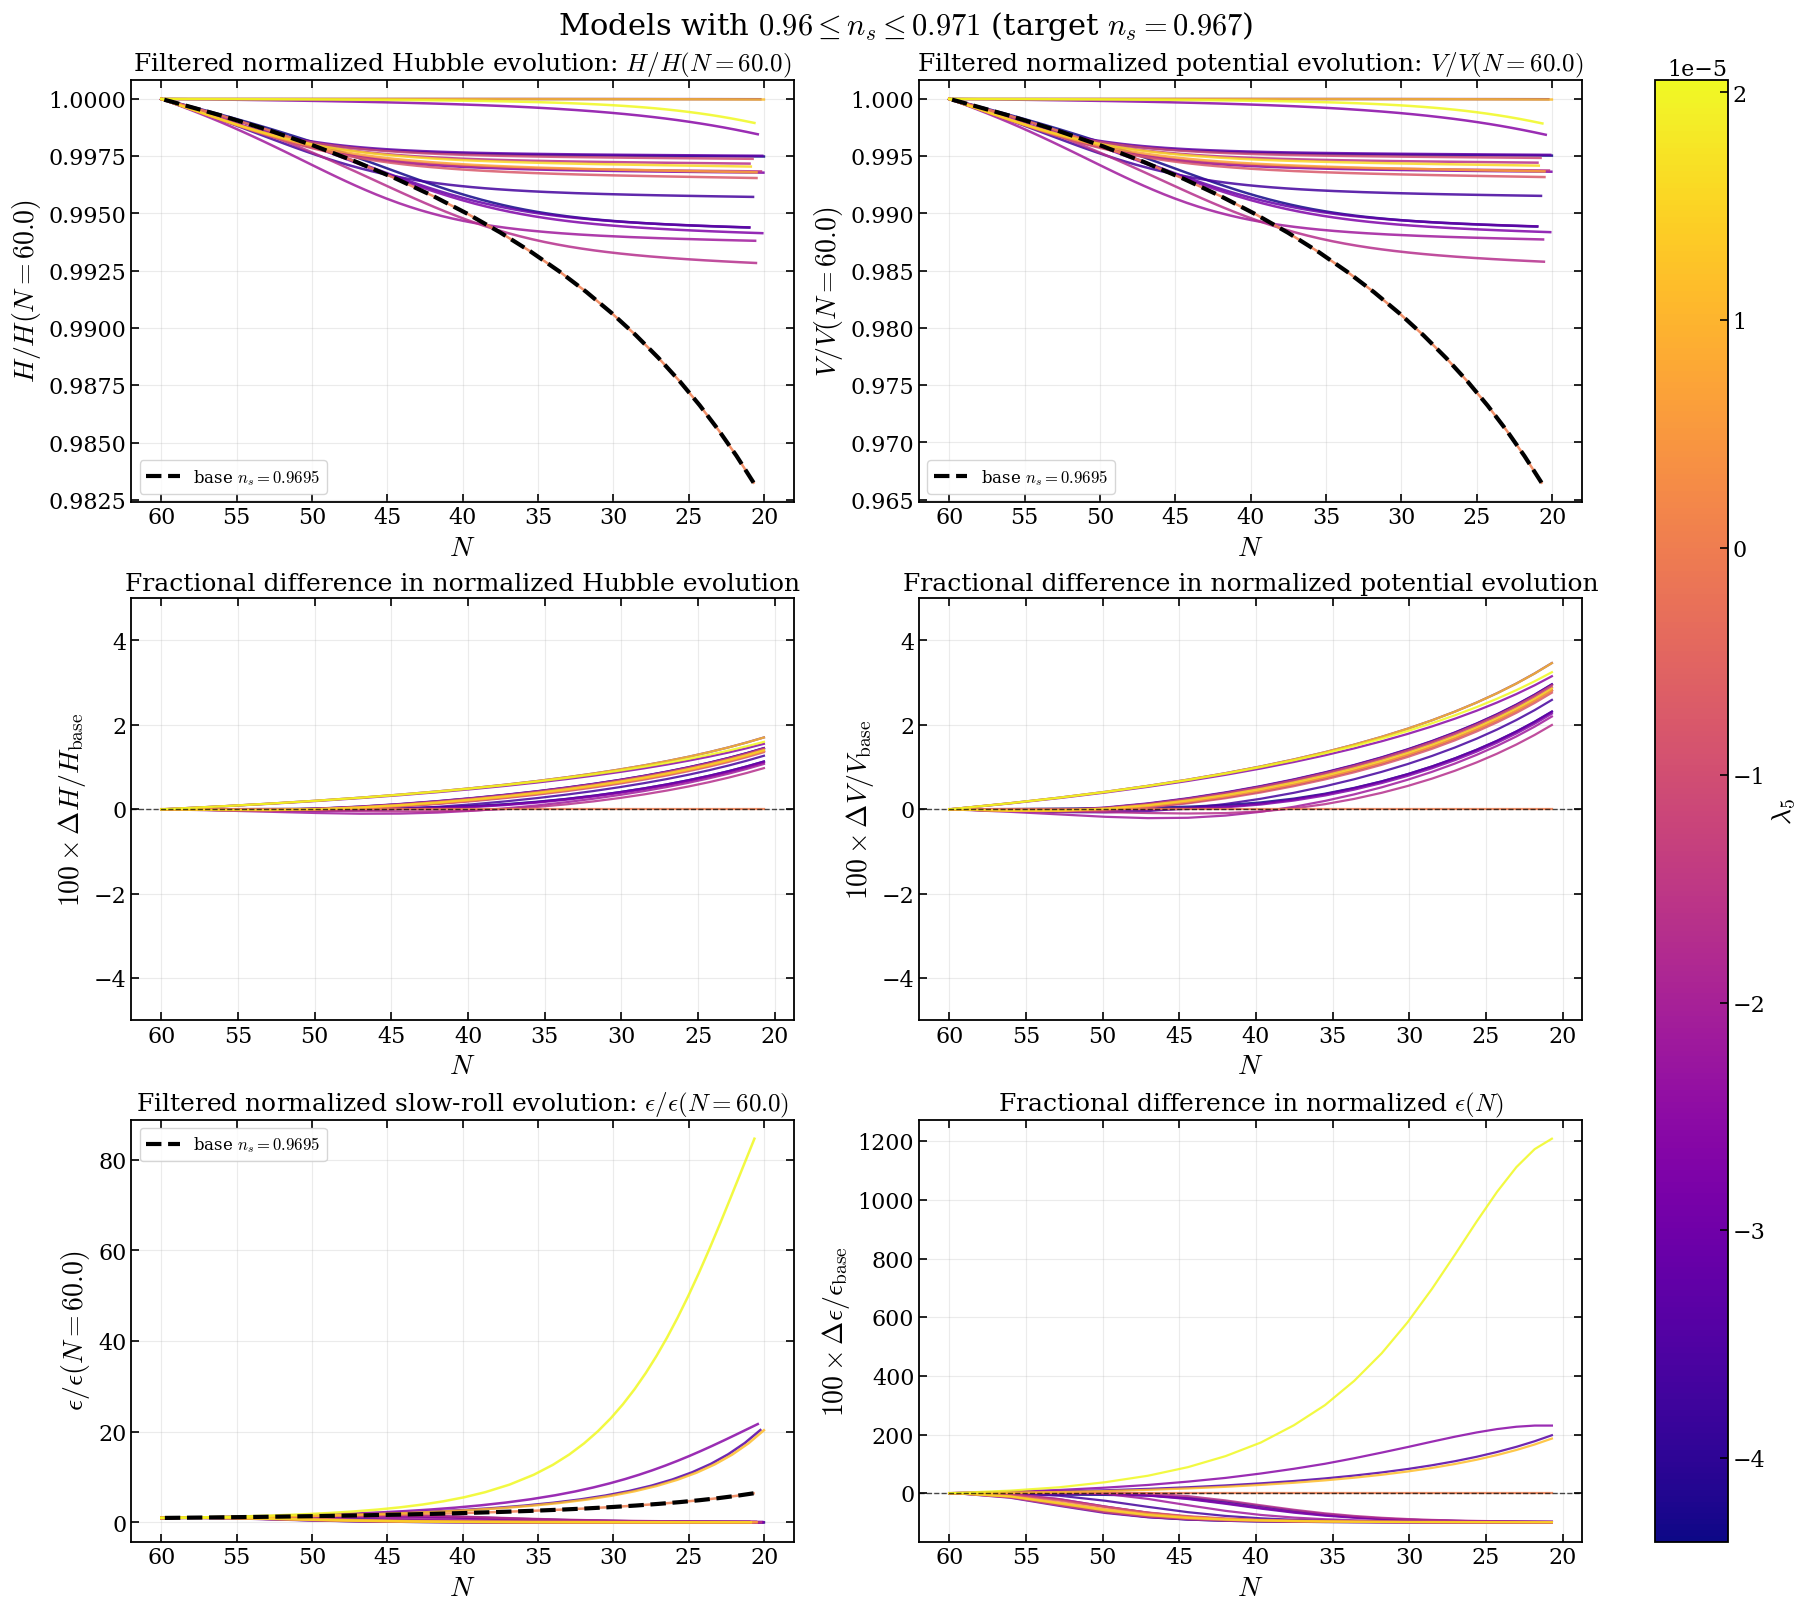

In [205]:
bg7_df = plot_filtered_background_by_ns(
    NEQS=7,
    lamX_values=lam4_values,
    baseX=6.87065e-08,
    base_path_root=base_path_root,
    ns_min=0.96,
    ns_max=0.971,
    N_ref=60.0,
    N_window=(20, 60),
    frac_ylim=(-5, 5),
    save_name="neqs7_lam4_background_3higherorder_random.png",
)

bg8_df = plot_filtered_background_by_ns(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.92461e-9,
    base_path_root=base_path_root,
    ns_min=0.96,
    ns_max=0.971,
    N_ref=60.0,
    N_window=(20, 60),
    frac_ylim=(-5, 5),
    save_name="neqs8_lam5_background_3higherorder_random.png",
)

Now, if I wanted to look at the observables for these models before applying any N_shift!

In [131]:
def plot_observable_drift_vs_lambda_distance(
    summary_file,
    lamX,
    base_value,
    ns_min=None,
    ns_max=None,
    ns_target=None,
    use_fractional_r=False,
    cmap_name="plasma",
    save_name=None,
    show=True,
):
    df = pd.read_csv(summary_file).copy()

    required_cols = [lamX, "n_s", "r", "alpha_s"]
    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}' in {summary_file}")

    df = df.sort_values(lamX)

    idx_base = (df[lamX] - base_value).abs().idxmin()

    base_lam = df.loc[idx_base, lamX]
    base_ns = df.loc[idx_base, "n_s"]
    base_r = df.loc[idx_base, "r"]
    base_alpha = df.loc[idx_base, "alpha_s"]

    df["delta_lamX"] = df[lamX] - base_lam
    df["abs_delta_lamX"] = np.abs(df["delta_lamX"])

    df["delta_ns"] = df["n_s"] - base_ns
    df["delta_alpha_s"] = df["alpha_s"] - base_alpha

    if use_fractional_r:
        df["delta_r_plot"] = (df["r"] - base_r) / base_r
        r_ylabel = r"$(r-r_{\rm base})/r_{\rm base}$"
        r_title = r"Fractional drift in $r$"
    else:
        df["delta_r_plot"] = df["r"] - base_r
        r_ylabel = r"$r-r_{\rm base}$"
        r_title = r"Drift in $r$"

    df["kept_by_ns_cut"] = True
    if ns_min is not None:
        df["kept_by_ns_cut"] &= df["n_s"] >= ns_min
    if ns_max is not None:
        df["kept_by_ns_cut"] &= df["n_s"] <= ns_max

    kept_df = df[df["kept_by_ns_cut"]].copy()

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 22,
        "axes.titlesize": 20,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 14,
        "figure.titlesize": 24,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(vmin=df[lamX].min(), vmax=df[lamX].max())

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(24, 6.5),
        constrained_layout=True,
    )
    
    for ax in axes:
        ax.ticklabel_format(
            axis='x',
            style='sci',
            scilimits=(0,0)
        )


    ax_r, ax_ns, ax_alpha = axes

    for ax, ycol, title, ylabel in [
        (ax_r, "delta_r_plot", r_title, r_ylabel),
        (ax_ns, "delta_ns", r"Drift in $n_s$", r"$n_s-n_{s,\rm base}$"),
        (ax_alpha, "delta_alpha_s", r"Drift in $\alpha_s$", r"$\alpha_s-\alpha_{s,\rm base}$"),
    ]:
        ax.scatter(
            df["delta_lamX"],
            df[ycol],
            c=df[lamX],
            cmap=cmap,
            norm=norm,
            s=70,
            alpha=0.28,
            edgecolor="none",
            label="all models",
        )

        if len(kept_df) > 0:
            ax.scatter(
                kept_df["delta_lamX"],
                kept_df[ycol],
                c=kept_df[lamX],
                cmap=cmap,
                norm=norm,
                s=100,
                alpha=0.9,
                edgecolor="black",
                linewidth=0.6,
                label=rf"${ns_min}\leq n_s\leq {ns_max}$" if ns_min is not None and ns_max is not None else "kept models",
            )

        ax.axhline(0.0, color="black", ls="--", lw=1.2, alpha=0.7)
        ax.axvline(0.0, color="black", ls="--", lw=1.2, alpha=0.7)

        ax.set_title(title)
        ax.set_xlabel(rf"$\Delta {lamX} = {lamX}-{lamX}_{{\rm base}}$")
        ax.set_ylabel(ylabel)

        ax.grid(True, alpha=0.25)
        ax.legend(loc="best", fontsize=12)

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=axes, pad=0.015, fraction=0.035)
    cbar.set_label(rf"${lamX}$", fontsize=22)
    cbar.ax.tick_params(labelsize=16)

    fig.suptitle(
        rf"Observable drift relative to base model across ${lamX}$ scan",
        fontsize=24,
    )

    print("\n=== Base model used for drift ===")
    print(f"{lamX}_base nearest = {base_lam:.10e}")
    print(f"n_s_base = {base_ns:.10f}")
    print(f"r_base = {base_r:.10e}")
    print(f"alpha_s_base = {base_alpha:.10e}")
    print(f"Total models = {len(df)}")
    print(f"Kept models = {len(kept_df)}")

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return df, kept_df


=== Base model used for drift ===
lam4_base nearest = 6.8706500000e-08
n_s_base = 0.9672013746
r_base = 3.1575282222e-03
alpha_s_base = -5.4457263931e-04
Total models = 20
Kept models = 20


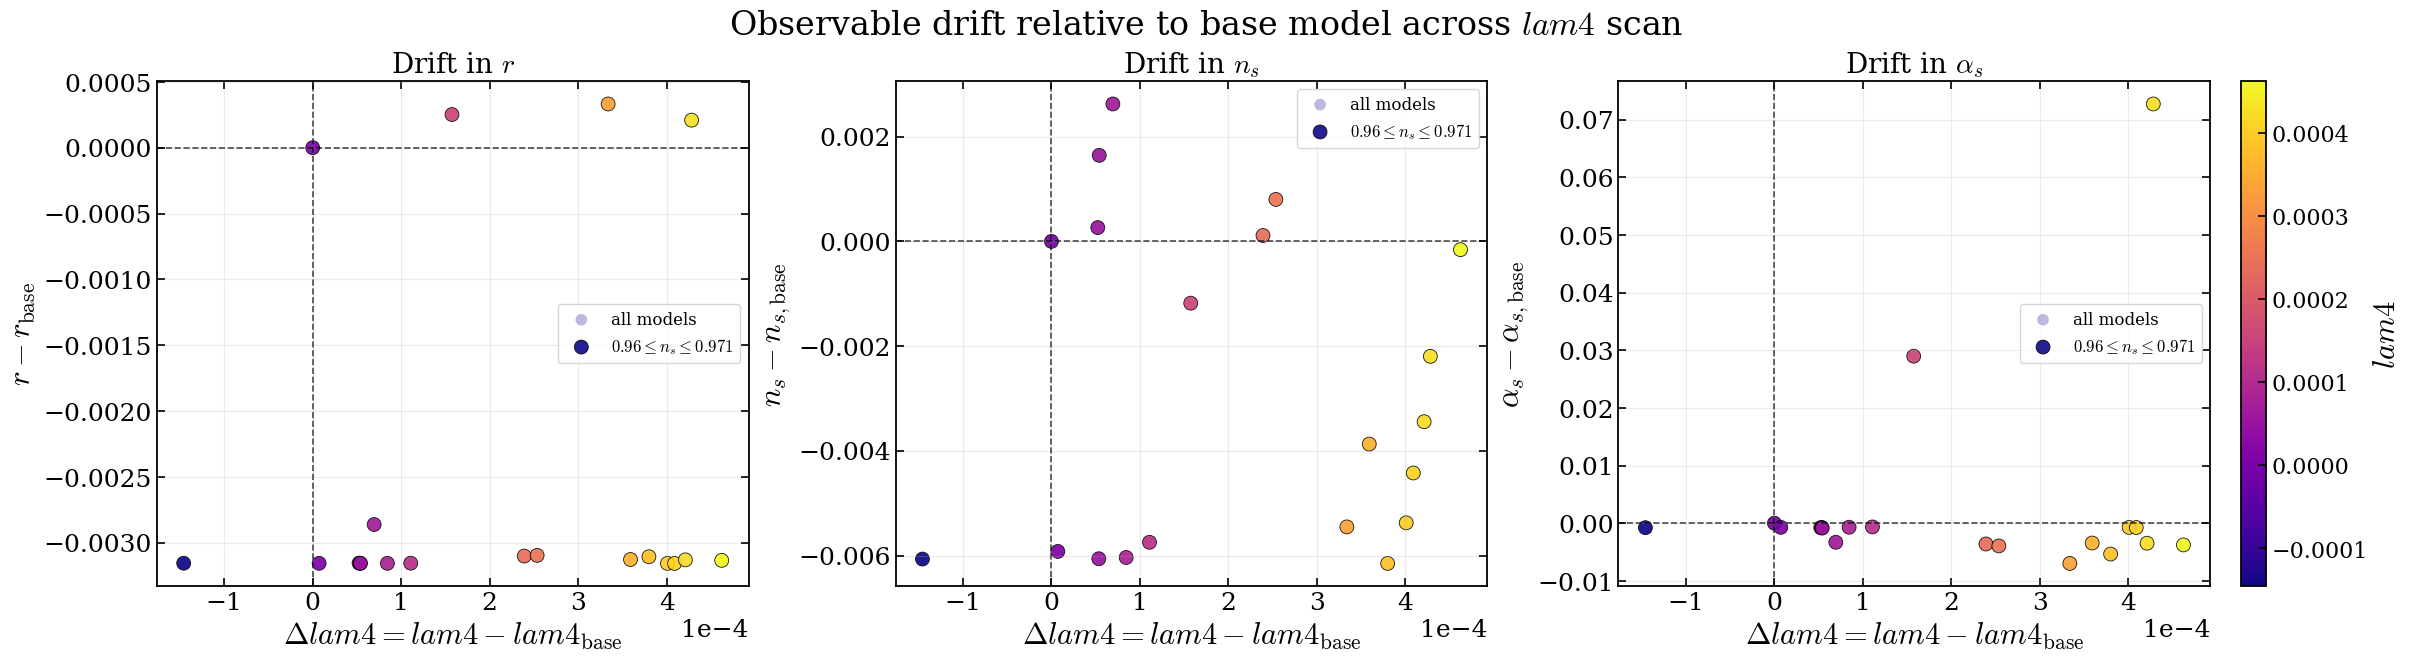


=== Base model used for drift ===
lam5_base nearest = -8.9246100000e-09
n_s_base = 0.9694853961
r_base = 2.7371100978e-03
alpha_s_base = -4.7038093487e-04
Total models = 20
Kept models = 20


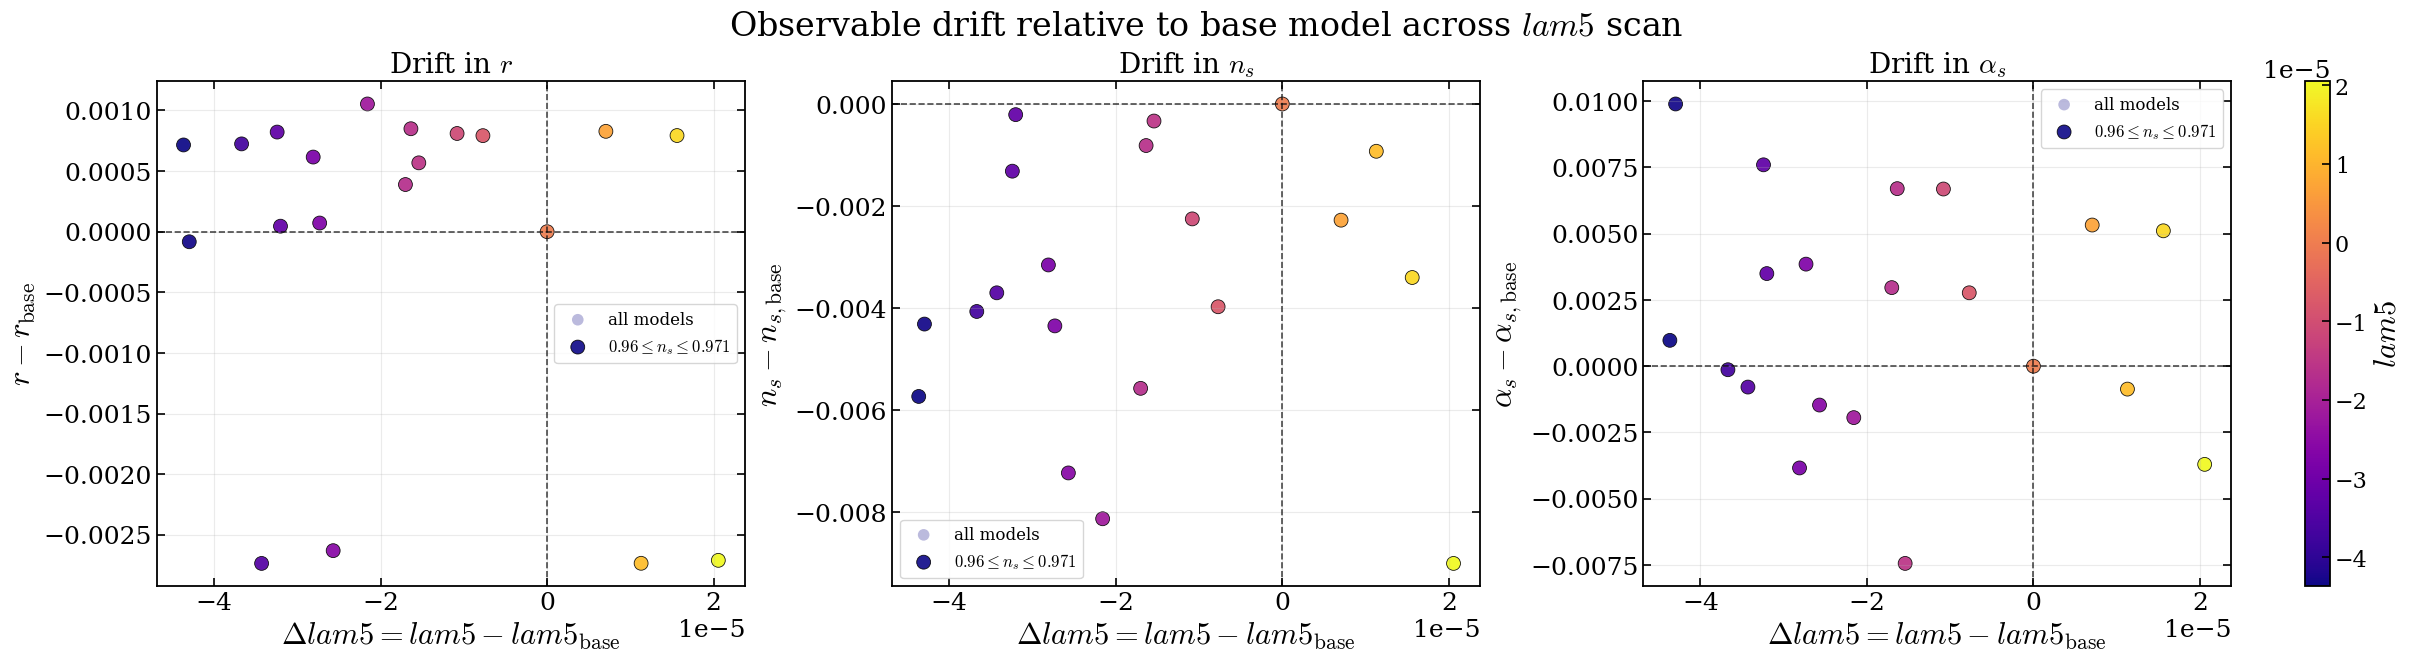

In [132]:
summary_file_neqs7 = (
    "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/"
    "inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/"
    "neqs7/neqs7_summary.csv"
)

drift7_df, drift7_kept = plot_observable_drift_vs_lambda_distance(
    summary_file=summary_file_neqs7,
    lamX="lam4",
    base_value=6.87065e-08,
    ns_min=0.96,
    ns_max=0.971,
    ns_target=0.967,
    use_fractional_r=False,
    save_name="neqs7_lam4_observable_drift_from_base.png",
)


summary_file_neqs8 = (
    "/Users/epmeador/Desktop/research/rwarthur/inflation_gravitywaves/"
    "inflation_code/Slow-Roll Parameters Tests/higgs_potential_tests/"
    "neqs8/neqs8_summary.csv"
)

drift8_df, drift8_kept = plot_observable_drift_vs_lambda_distance(
    summary_file=summary_file_neqs8,
    lamX="lam5",
    base_value=-8.92461e-9,
    ns_min=0.96,
    ns_max=0.971,
    ns_target=0.967,
    use_fractional_r=False,
    save_name="neqs8_lam5_observable_drift_from_base.png",
)


# AFTER APPLYING N-SHIFT

Now, we are interested in seeing what these models appear like when we compare their $\Delta$N shift to that of the base model. The expectation is that their error in these plots decreases significantly.

In [133]:
def plot_k_shift_equivalence_scan_2x2(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    k_norm=0.05,
    k_min_scalar=None,
    k_max_scalar=10.0,

    frac_ylim=(-0.6, 0.6),
    scalar_ylim=None,
    tensor_ylim=None,

    cmap_name="plasma",
    save_name=None,
):
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": [
            "Computer Modern Roman",
            "Times New Roman",
            "DejaVu Serif",
        ],
        "mathtext.fontset": "cm",

        "axes.labelsize": 16,
        "axes.titlesize": 15,
        "figure.titlesize": 18,

        "xtick.labelsize": 13,
        "ytick.labelsize": 13,

        "legend.fontsize": 11,

        "axes.linewidth": 1.2,

        "xtick.direction": "in",
        "ytick.direction": "in",

        "xtick.top": True,
        "ytick.right": True,

        "xtick.major.size": 6,
        "ytick.major.size": 6,

        "xtick.minor.size": 3,
        "ytick.minor.size": 3,

        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    })

    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array(
            [x[0] if isinstance(x, tuple) else x for x in vals],
            dtype=float,
        )

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_specs_local(value):
        folder = folder_for(value)

        s = np.loadtxt(
            os.path.join(folder, f"spec_s_neqs{NEQS}.dat")
        )

        t = np.loadtxt(
            os.path.join(folder, f"spec_t_neqs{NEQS}.dat")
        )

        k_s = s[:, 0]
        Ps = np.abs(s[:, 1])

        k_t = t[:, 0]
        Pt = np.abs(t[:, 1])

        k_s, Ps = prepare_increasing(k_s, Ps)
        k_t, Pt = prepare_increasing(k_t, Pt)

        return k_s, Ps, k_t, Pt

    def get_original_N_end(value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[
            np.isclose(summary_df[scan_name], value)
        ]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for {scan_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside shifted k range "
                f"[{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(
                f"Reference spectrum too small at k={k_ref}"
            )

        return k, P / P_ref, P_ref

    def frac_on_base_grid(
        k_base,
        P_base,
        k_cmp,
        P_cmp,
        kmin=None,
        kmax=None,
    ):
        k_base, P_base = prepare_increasing(k_base, P_base)
        k_cmp, P_cmp = prepare_increasing(k_cmp, P_cmp)

        xmin = max(k_base.min(), k_cmp.min())
        xmax = min(k_base.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        mask = (k_base >= xmin) & (k_base <= xmax)

        k_use = k_base[mask]
        P_base_use = P_base[mask]

        if len(k_use) == 0:
            raise ValueError(
                f"No overlapping k range after cuts: "
                f"kmin={kmin}, kmax={kmax}"
            )

        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp)

        frac = (P_cmp_interp - P_base_use) / P_base_use

        return k_use, frac

    def scalar_k_mask(k):
        mask = np.ones_like(k, dtype=bool)

        if k_min_scalar is not None:
            mask &= k >= k_min_scalar

        if k_max_scalar is not None:
            mask &= k <= k_max_scalar

        return mask

    lam_vals = sanitize_lam_values(lamX_values)

    base_N_end = get_original_N_end(baseX)

    (
        k_s_base_raw,
        Ps_base_raw,
        k_t_base_raw,
        Pt_base_raw,
    ) = load_specs_local(baseX)

    k_s_base, Ps_base_norm, _ = normalize_at_k(
        k_s_base_raw,
        Ps_base_raw,
        k_norm,
    )

    k_t_base, Pt_base_norm, _ = normalize_at_k(
        k_t_base_raw,
        Pt_base_raw,
        k_norm,
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(13.5, 9.5),
        constrained_layout=True,
    )

    ax_ps, ax_pt = axes[0]
    ax_ps_err, ax_pt_err = axes[1]

    cmap = plt.get_cmap(cmap_name)

    norm = mcolors.Normalize(
        vmin=np.min(lam_vals),
        vmax=np.max(lam_vals),
    )

    rows = []

    for value in lam_vals:
        try:
            model_N_end = get_original_N_end(value)
            deltaN = model_N_end - base_N_end

            (
                k_s_raw,
                Ps_raw,
                k_t_raw,
                Pt_raw,
            ) = load_specs_local(value)

            k_s_shifted = k_s_raw * np.exp(-deltaN)
            k_t_shifted = k_t_raw * np.exp(-deltaN)

            k_s, Ps_norm, _ = normalize_at_k(
                k_s_shifted,
                Ps_raw,
                k_norm,
            )

            k_t, Pt_norm, _ = normalize_at_k(
                k_t_shifted,
                Pt_raw,
                k_norm,
            )

            k_ps_err, frac_ps = frac_on_base_grid(
                k_s_base,
                Ps_base_norm,
                k_s,
                Ps_norm,
                kmin=k_min_scalar,
                kmax=k_max_scalar,
            )

            k_pt_err, frac_pt = frac_on_base_grid(
                k_t_base,
                Pt_base_norm,
                k_t,
                Pt_norm,
                kmin=None,
                kmax=None,
            )

            color = cmap(norm(value))

            mask_s = scalar_k_mask(k_s)

            ax_ps.loglog(
                k_s[mask_s],
                Ps_norm[mask_s],
                color=color,
                lw=1.25,
                alpha=0.75,
            )

            ax_pt.loglog(
                k_t,
                Pt_norm,
                color=color,
                lw=1.25,
                alpha=0.75,
            )

            ax_ps_err.semilogx(
                k_ps_err,
                100.0 * frac_ps,
                color=color,
                lw=1.1,
                alpha=0.75,
            )

            ax_pt_err.semilogx(
                k_pt_err,
                100.0 * frac_pt,
                color=color,
                lw=1.1,
                alpha=0.75,
            )

            rows.append({
                scan_name: value,
                "original_N_end": model_N_end,
                "deltaN_from_base": deltaN,
                "exp_minus_deltaN": np.exp(-deltaN),
                "mean_dPs_pct": 100.0 * np.nanmean(frac_ps),
                "max_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),
                "mean_dPt_pct": 100.0 * np.nanmean(frac_pt),
                "max_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
            })

        except FileNotFoundError:
            print(
                f"Missing files for {scan_name}={value:.5e}"
            )

        except ValueError as e:
            print(
                f"Skipping {scan_name}={value:.5e}: {e}"
            )

    mask_base_s = scalar_k_mask(k_s_base)

    ax_ps.loglog(
        k_s_base[mask_base_s],
        Ps_base_norm[mask_base_s],
        color="black",
        lw=2.4,
        ls="--",
        label=rf"Reference ${scan_symbol}={baseX:.2e}$",
    )

    ax_pt.loglog(
        k_t_base,
        Pt_base_norm,
        color="black",
        lw=2.4,
        ls="--",
        label=rf"Reference ${scan_symbol}={baseX:.2e}$",
    )

    for ax in [ax_ps_err, ax_pt_err]:
        ax.axhline(
            0.0,
            color="black",
            ls="--",
            lw=1.0,
            alpha=0.6,
        )

    ax_ps.axvline(
        k_norm,
        color="black",
        ls=":",
        lw=1.1,
        alpha=0.7,
    )

    ax_pt.axvline(
        k_norm,
        color="black",
        ls=":",
        lw=1.1,
        alpha=0.7,
    )

    ax_ps.set_title(r"Scalar spectra")
    ax_pt.set_title(r"Tensor spectra")

    ax_ps_err.set_title(r"Scalar fractional differences")
    ax_pt_err.set_title(r"Tensor fractional differences")

    ax_ps.set_xlabel(r"$k$")
    ax_pt.set_xlabel(r"$k$")
    ax_ps_err.set_xlabel(r"$k$")
    ax_pt_err.set_xlabel(r"$k$")

    ax_ps.set_ylabel(rf"$P_s/P_s(k={k_norm})$")
    ax_pt.set_ylabel(rf"$P_t/P_t(k={k_norm})$")

    ax_ps_err.set_ylabel(r"$100 \times \Delta P_s/P_s \; (\%)$")
    ax_pt_err.set_ylabel(r"$100 \times \Delta P_t/P_t \; (\%)$")

    xmin_scalar = (
        k_min_scalar
        if k_min_scalar is not None
        else np.min(k_s_base[mask_base_s])
    )

    xmax_scalar = (
        k_max_scalar
        if k_max_scalar is not None
        else np.max(k_s_base[mask_base_s])
    )

    ax_ps.set_xlim(xmin_scalar, xmax_scalar)
    ax_ps_err.set_xlim(xmin_scalar, xmax_scalar)

    ax_pt.set_xlim(k_t_base.min(), k_t_base.max())
    ax_pt_err.set_xlim(k_t_base.min(), k_t_base.max())

    ax_ps_err.set_ylim(*frac_ylim)
    ax_pt_err.set_ylim(*frac_ylim)

    if scalar_ylim is not None:
        ax_ps.set_ylim(*scalar_ylim)

    if tensor_ylim is not None:
        ax_pt.set_ylim(*tensor_ylim)

    for ax in axes.ravel():
        ax.minorticks_on()

        ax.grid(
            True,
            which="major",
            alpha=0.25,
            lw=0.8,
        )

        ax.grid(
            True,
            which="minor",
            alpha=0.12,
            lw=0.5,
        )

        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
        )

        handles, labels = ax.get_legend_handles_labels()

        if len(handles) > 0:
            ax.legend(
                frameon=False,
                loc="best",
                handlelength=2.6,
                borderpad=0.4,
            )

    sm = cm.ScalarMappable(
        cmap=cmap,
        norm=norm,
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes,
        pad=0.025,
        fraction=0.035,
    )

    cbar.set_label(
        rf"${scan_symbol}$",
        fontsize=16,
    )

    cbar.ax.tick_params(
        labelsize=12,
        direction="in",
    )

    fig.suptitle(
        rf"NEQS={NEQS}: spectra shifted relative to the reference model",
        y=1.02,
    )

    if save_name is None:
        save_name = (
            f"neqs{NEQS}_"
            f"{scan_name}_"
            f"kshifted_spectra_"
            f"kmin{k_min_scalar}_"
            f"kmax{k_max_scalar}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    stats_df = pd.DataFrame(rows)

    if not stats_df.empty:
        print(
            "\n=== Shifted spectra fractional-error summary ==="
        )

        print(
            stats_df[[
                scan_name,
                "deltaN_from_base",
                "mean_dPs_pct",
                "max_dPs_pct",
                "mean_dPt_pct",
                "max_dPt_pct",
            ]].to_string(index=False)
        )

    return stats_df

Skipping lam4=-1.45714e-04: k_ref=0.05 outside shifted k range [3.203e+60, 2.659e+80]
Skipping lam4=7.27565e-06: k_ref=0.05 outside shifted k range [1.815e+64, 1.507e+84]
Skipping lam4=5.24121e-05: k_ref=0.05 outside shifted k range [1.550e+56, 1.287e+76]
Skipping lam4=5.35739e-05: k_ref=0.05 outside shifted k range [6.523e+63, 5.417e+83]
Skipping lam4=5.40483e-05: k_ref=0.05 outside shifted k range [7.209e+51, 5.986e+71]
Skipping lam4=6.94521e-05: k_ref=0.05 outside shifted k range [1.945e-23, 1.615e-03]
Skipping lam4=8.44573e-05: k_ref=0.05 outside shifted k range [1.486e+66, 1.234e+86]
Skipping lam4=1.10824e-04: k_ref=0.05 outside shifted k range [1.050e+71, 8.723e+90]
Skipping lam4=2.39069e-04: k_ref=0.05 outside shifted k range [1.017e-24, 8.448e-05]
Skipping lam4=2.53617e-04: k_ref=0.05 outside shifted k range [5.499e-26, 4.566e-06]
Skipping lam4=3.59134e-04: k_ref=0.05 outside shifted k range [1.387e-24, 1.151e-04]
Skipping lam4=4.00874e-04: k_ref=0.05 outside shifted k range [3

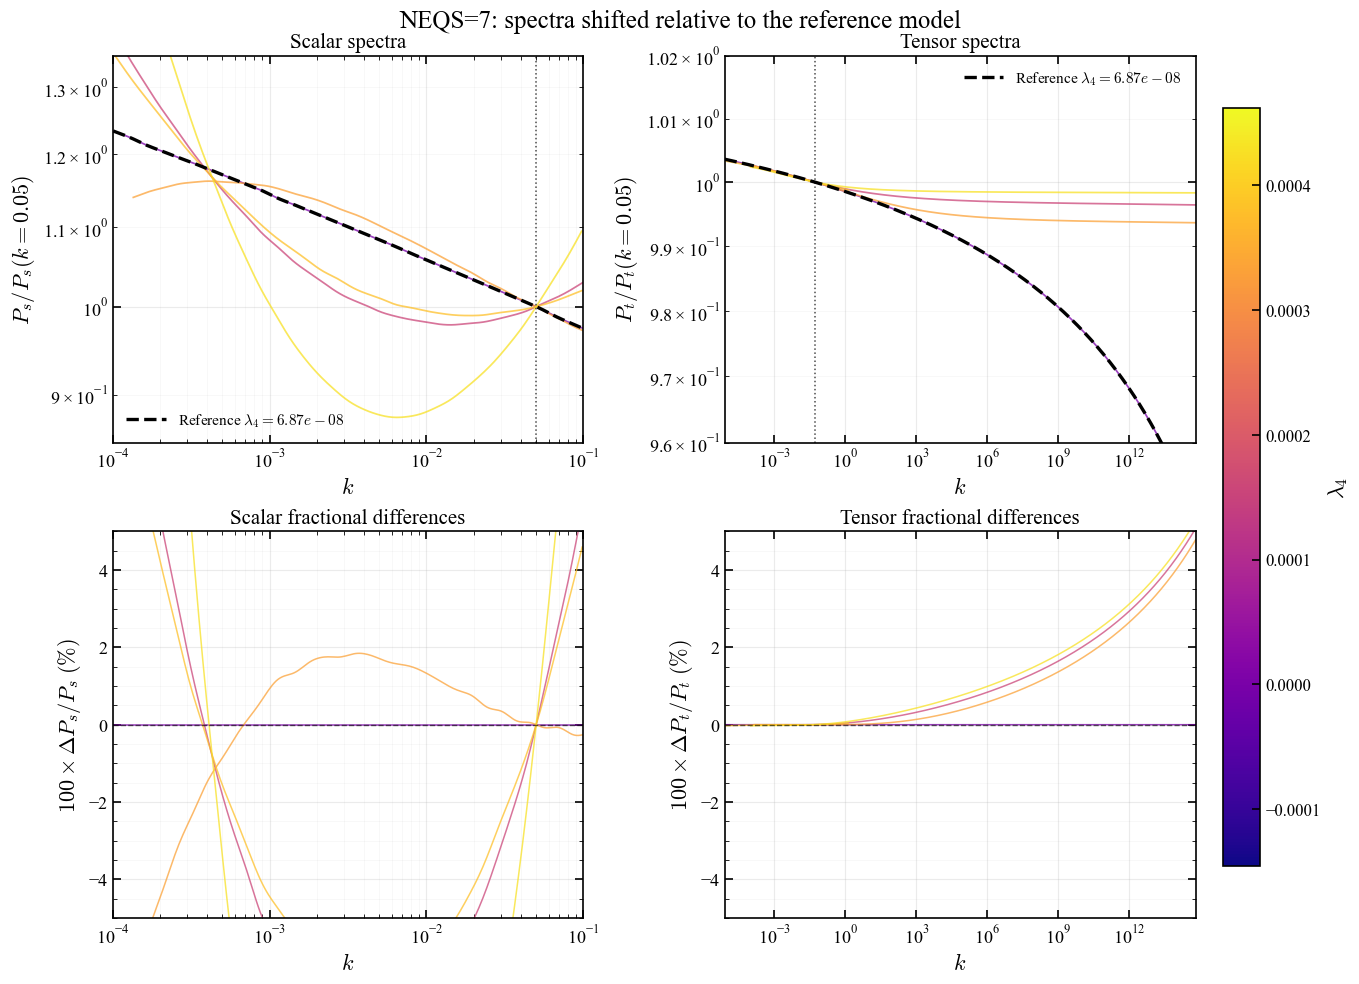


=== Shifted spectra fractional-error summary ===
        lam4  deltaN_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
6.870650e-08          0.000000      0.000000     0.000000      0.000000     0.000000
1.574288e-04         -2.567774     -2.533640    12.223221      1.246581     5.070031
3.338464e-04         -2.856304      0.033029     6.565029      1.068231     4.776565
3.799333e-04         33.806834     -2.101127     9.736317     -0.002656     0.040460
4.281542e-04         -2.526572     -4.728882    39.533607      1.360209     5.268572
Skipping lam5=-3.43050e-05: k_ref=0.05 outside shifted k range [3.072e+69, 2.551e+89]
Skipping lam5=-2.57068e-05: k_ref=0.05 outside shifted k range [1.579e-23, 1.311e-03]
Skipping lam5=-2.15908e-05: k_ref=0.05 outside shifted k range [1.241e-01, 1.031e+19]
Skipping lam5=1.12808e-05: k_ref=0.05 outside shifted k range [1.202e+60, 9.983e+79]
Skipping lam5=2.05545e-05: k_ref=0.05 outside shifted k range [3.142e-23, 2.609e-03]


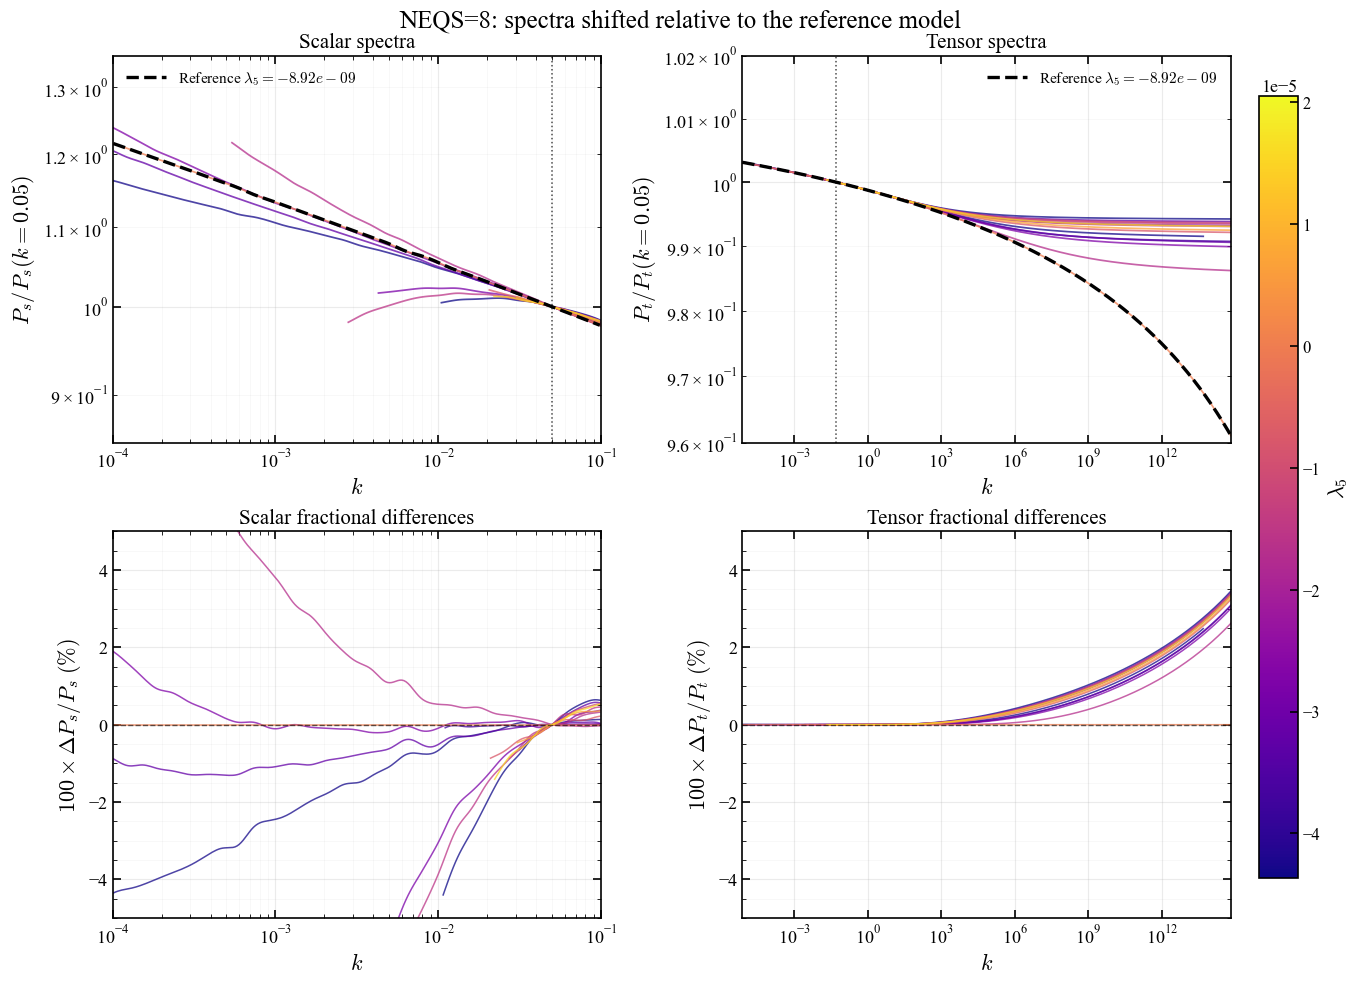


=== Shifted spectra fractional-error summary ===
         lam5  deltaN_from_base  mean_dPs_pct  max_dPs_pct  mean_dPt_pct  max_dPt_pct
-4.368160e-05         -7.202026     -1.085599     4.400947      0.874715     3.451071
-4.299231e-05          2.591112     -1.691402     4.348857      0.478795     2.482182
-3.670782e-05         -7.248876     -0.018497     0.079972      0.683366     3.088784
-3.243509e-05         -8.295805      0.090021     0.643637      0.876099     3.409795
-3.203578e-05         -0.160869     -0.684713     1.310086      0.576499     3.073155
-2.810717e-05         -6.311915     -1.782299     6.131420      0.798941     3.345703
-2.732926e-05         -0.787295      0.183921     1.888606      0.556900     3.002799
-1.702759e-05         -4.240643      1.433231     5.203653      0.447339     2.618427
-1.636978e-05         -8.522532      0.086959     0.322295      0.838611     3.330348
-1.542184e-05         -5.885628     -3.084926    10.573056      0.806450     3.374511
-1.0

In [134]:
shift_df = plot_k_shift_equivalence_scan_2x2(
    NEQS=7,
    lamX_values=lam4_values,
    baseX=6.87065e-08,
    base_path_root=base_path_root,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    frac_ylim=(-5, 5),
    scalar_ylim=(0.85, 1.35),
    tensor_ylim=(0.96, 1.02),
    cmap_name="plasma",
    save_name="neqs7_lam4_shifted_spectra_2x2.png",
)


shift_df = plot_k_shift_equivalence_scan_2x2(
    NEQS=8,
    lamX_values=lam5_values,
    baseX=-8.92461e-9,
    base_path_root=base_path_root,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    frac_ylim=(-5, 5),
    scalar_ylim=(0.85, 1.35),
    tensor_ylim=(0.96, 1.02),
    cmap_name="plasma",
    save_name="neqs8_lam5_shifted_spectra_2x2.png",
)



To compare the background variables with the shifted N we can do the following:


In [135]:
def plot_shifted_background_by_ns(
    NEQS,
    lamX_values,
    baseX,
    base_path_root,
    ns_min=0.96,
    ns_max=0.971,
    ns_target=0.967,
    N_ref=60.0,
    N_window=None,
    cmap_name="plasma",
    frac_ylim=None,
    save_name=None,
    show=True,
):
    scan_name, scan_symbol = SCAN_INFO[NEQS]

    def sanitize_lam_values(vals):
        return np.array([x[0] if isinstance(x, tuple) else x for x in vals], dtype=float)

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(base_path_root, f"neqs{NEQS}", f"{scan_name}_{val_str}")

    def load_observables(value):
        arr = np.loadtxt(os.path.join(folder_for(value), f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def load_path(value):
        val_str = f"{value:.10e}"
        f = os.path.join(folder_for(value), f"path_neqs{NEQS}_{scan_name}_{val_str}.dat")
        return pd.read_csv(f, sep=r"\s+", header=None).values

    def get_original_N_end(value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)

        matches = summary_df.loc[np.isclose(summary_df[scan_name], value)]

        if len(matches) == 0:
            raise ValueError(f"No summary row found for {scan_name}={value:.10e}")

        return float(matches.iloc[0]["original_N_end"])

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_at_ref(N, Y, N_ref):
        N_use, Y_use = prepare_increasing(N, Y)

        if not (np.min(N_use) <= N_ref <= np.max(N_use)):
            raise ValueError(
                f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
            )

        Y_ref = np.interp(N_ref, N_use, Y_use)

        if np.abs(Y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at N_ref={N_ref}")

        return N_use, Y_use / Y_ref, Y_ref

    def apply_N_window(N, Y):
        if N_window is None:
            return N, Y

        Nmin, Nmax = N_window
        mask = (N >= Nmin) & (N <= Nmax)
        return N[mask], Y[mask]

    def fractional_error_on_base_grid(N_base, Y_base, N_model, Y_model):
        N_base, Y_base = prepare_increasing(N_base, Y_base)
        N_model, Y_model = prepare_increasing(N_model, Y_model)

        Nmin = max(np.min(N_base), np.min(N_model))
        Nmax = min(np.max(N_base), np.max(N_model))

        if N_window is not None:
            Nmin = max(Nmin, N_window[0])
            Nmax = min(Nmax, N_window[1])

        mask = (N_base >= Nmin) & (N_base <= Nmax)

        N_use = N_base[mask]
        Y_base_use = Y_base[mask]

        if len(N_use) == 0:
            raise ValueError("No overlapping shifted N range between model and base.")

        Y_model_interp = np.interp(N_use, N_model, Y_model)

        frac = (Y_model_interp - Y_base_use) / Y_base_use

        return N_use, frac

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],

        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 14,
        "figure.titlesize": 22,

        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    lam_vals = sanitize_lam_values(lamX_values)

    r_base, ns_base, alpha_base = load_observables(baseX)
    base_N_end = get_original_N_end(baseX)

    base_data = load_path(baseX)

    H_base = base_data[:, 1]
    N_base = base_data[:, NEQS]
    V_base = base_data[:, NEQS + 1]

    # Base model has zero shift by construction.
    N_base_shifted = N_base.copy()

    N_base_H, H_base_norm, H_ref = normalize_at_ref(N_base_shifted, H_base, N_ref)
    N_base_V, V_base_norm, V_ref = normalize_at_ref(N_base_shifted, V_base, N_ref)

    N_base_H_plot, H_base_plot = apply_N_window(N_base_H, H_base_norm)
    N_base_V_plot, V_base_plot = apply_N_window(N_base_V, V_base_norm)

    rows = []
    kept_models = []

    for lamX in lam_vals:
        try:
            r, ns, alpha_s = load_observables(lamX)
            model_N_end = get_original_N_end(lamX)

            deltaN = model_N_end - base_N_end

            keep = ns_min <= ns <= ns_max

            row = {
                "lamX": lamX,
                "r": r,
                "ns": ns,
                "alpha_s": alpha_s,
                "original_N_end": model_N_end,
                "deltaN_from_base": deltaN,
                "delta_ns_from_base": ns - ns_base,
                "delta_ns_from_target": ns - ns_target,
                "kept_by_ns_cut": keep,
            }
            rows.append(row)

            if not keep:
                continue

            data = load_path(lamX)

            H = data[:, 1]
            N = data[:, NEQS]
            V = data[:, NEQS + 1]

            # This is the background analogue of k -> k exp(-DeltaN).
            N_shifted = N + deltaN

            N_H, H_norm, _ = normalize_at_ref(N_shifted, H, N_ref)
            N_V, V_norm, _ = normalize_at_ref(N_shifted, V, N_ref)

            N_H_plot, H_plot = apply_N_window(N_H, H_norm)
            N_V_plot, V_plot = apply_N_window(N_V, V_norm)

            N_frac_H, frac_H = fractional_error_on_base_grid(
                N_base_H,
                H_base_norm,
                N_H,
                H_norm,
            )

            N_frac_V, frac_V = fractional_error_on_base_grid(
                N_base_V,
                V_base_norm,
                N_V,
                V_norm,
            )

            kept_models.append({
                **row,
                "N_H": N_H_plot,
                "H_N": H_plot,
                "N_V": N_V_plot,
                "V_N": V_plot,
                "N_frac_H": N_frac_H,
                "frac_H": frac_H,
                "N_frac_V": N_frac_V,
                "frac_V": frac_V,
                "mean_dH_pct": 100.0 * np.nanmean(frac_H),
                "max_dH_pct": 100.0 * np.nanmax(np.abs(frac_H)),
                "mean_dV_pct": 100.0 * np.nanmean(frac_V),
                "max_dV_pct": 100.0 * np.nanmax(np.abs(frac_V)),
            })

        except FileNotFoundError:
            print(f"Missing files for {scan_name}={lamX:.5e}")
        except ValueError as e:
            print(f"Skipping {scan_name}={lamX:.5e}: {e}")

    stats_df = pd.DataFrame(rows).sort_values("ns")

    if len(kept_models) > 0:
        kept_df = pd.DataFrame(kept_models).drop(
            columns=[
                "N_H", "H_N", "N_V", "V_N",
                "N_frac_H", "frac_H", "N_frac_V", "frac_V",
            ]
        )
    else:
        kept_df = stats_df[stats_df["kept_by_ns_cut"]].copy()

    print("\n=== Shifted background models summary ===")
    print(f"Total loaded: {len(stats_df)}")
    print(f"Base ns: {ns_base:.6f}")
    print(f"Base original_N_end: {base_N_end:.6f}")
    print(f"Models in ns window [{ns_min}, {ns_max}]: {len(kept_models)}")

    if len(kept_models) > 0:
        print("\n=== Shifted background fractional errors in percent ===")
        print(
            kept_df[[
                "lamX",
                "ns",
                "deltaN_from_base",
                "mean_dH_pct",
                "max_dH_pct",
                "mean_dV_pct",
                "max_dV_pct",
            ]].to_string(index=False)
        )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(20, 18),
        constrained_layout=True,
    )

    ax_HN, ax_VN = axes[0]
    ax_Herr, ax_Verr = axes[1]

    if len(kept_models) > 0:
        lam_kept = np.array([m["lamX"] for m in kept_models])
        cmap = plt.get_cmap(cmap_name)
        norm = mcolors.Normalize(vmin=np.min(lam_kept), vmax=np.max(lam_kept))

        for m in kept_models:
            color = cmap(norm(m["lamX"]))

            ax_HN.plot(m["N_H"], m["H_N"], color=color, lw=1.8, alpha=0.85)
            ax_VN.plot(m["N_V"], m["V_N"], color=color, lw=1.8, alpha=0.85)

            ax_Herr.plot(
                m["N_frac_H"],
                100.0 * m["frac_H"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

            ax_Verr.plot(
                m["N_frac_V"],
                100.0 * m["frac_V"],
                color=color,
                lw=1.6,
                alpha=0.85,
            )

        sm = cm.ScalarMappable(cmap=cmap, norm=norm)
        fig.colorbar(sm, ax=axes, label=rf"${scan_symbol}$")

    ax_HN.plot(
        N_base_H_plot,
        H_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_VN.plot(
        N_base_V_plot,
        V_base_plot,
        color="black",
        lw=3,
        ls="--",
        label=rf"base $n_s={ns_base:.4f}$",
    )

    ax_Herr.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)
    ax_Verr.axhline(0.0, color="black", ls="--", lw=1.0, alpha=0.7)

    ax_HN.set_title(rf"Shifted normalized Hubble evolution: $H/H(N={N_ref})$")
    ax_VN.set_title(rf"Shifted normalized potential evolution: $V/V(N={N_ref})$")
    ax_Herr.set_title(r"Shifted fractional difference in normalized Hubble evolution")
    ax_Verr.set_title(r"Shifted fractional difference in normalized potential evolution")

    ax_HN.set_xlabel(r"$N_{\rm shifted}$")
    ax_VN.set_xlabel(r"$N_{\rm shifted}$")
    ax_Herr.set_xlabel(r"$N_{\rm shifted}$")
    ax_Verr.set_xlabel(r"$N_{\rm shifted}$")

    ax_HN.set_ylabel(rf"$H/H(N={N_ref})$")
    ax_VN.set_ylabel(rf"$V/V(N={N_ref})$")
    ax_Herr.set_ylabel(r"$100\times\Delta H/H_{\rm base}$")
    ax_Verr.set_ylabel(r"$100\times\Delta V/V_{\rm base}$")

    if frac_ylim is not None:
        ax_Herr.set_ylim(frac_ylim)
        ax_Verr.set_ylim(frac_ylim)

    for ax in axes.ravel():
        ax.invert_xaxis()
        ax.grid(True, alpha=0.25)

        handles, labels = ax.get_legend_handles_labels()
        if len(handles) > 0:
            ax.legend(fontsize=12)

    fig.suptitle(
        rf"Shifted background comparison: ${ns_min} \leq n_s \leq {ns_max}$ "
        rf"(target $n_s={ns_target}$)",
        fontsize=22,
    )

    if save_name is None:
        save_name = f"neqs{NEQS}_{scan_name}_shifted_background_errors.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return kept_df

Skipping lam4=-1.45714e-04: N_ref=60.0 outside range [-151.08153847556127, -91.08153947556127]
Skipping lam4=7.27565e-06: N_ref=60.0 outside range [-159.72402832865134, -99.72402932865134]
Skipping lam4=5.24121e-05: N_ref=60.0 outside range [-141.1452527436477, -81.14525374364769]
Skipping lam4=5.35739e-05: N_ref=60.0 outside range [-158.70067332701524, -98.70067432701524]
Skipping lam4=5.40483e-05: N_ref=60.0 outside range [-131.1695968462658, -71.16959784626579]
Skipping lam4=8.44573e-05: N_ref=60.0 outside range [-164.12919646541218, -104.12919746541218]
Skipping lam4=1.10824e-04: N_ref=60.0 outside range [-175.29526927176028, -115.29527027176027]
Skipping lam4=1.57429e-04: N_ref=60.0 outside range [-2.5677728098492, 57.4322261901508]
Skipping lam4=3.33846e-04: N_ref=60.0 outside range [-2.8563031329164206, 57.14369586708358]
Skipping lam4=4.00874e-04: N_ref=60.0 outside range [-158.0686787623755, -98.0686797623755]
Skipping lam4=4.08878e-04: N_ref=60.0 outside range [-153.451048484

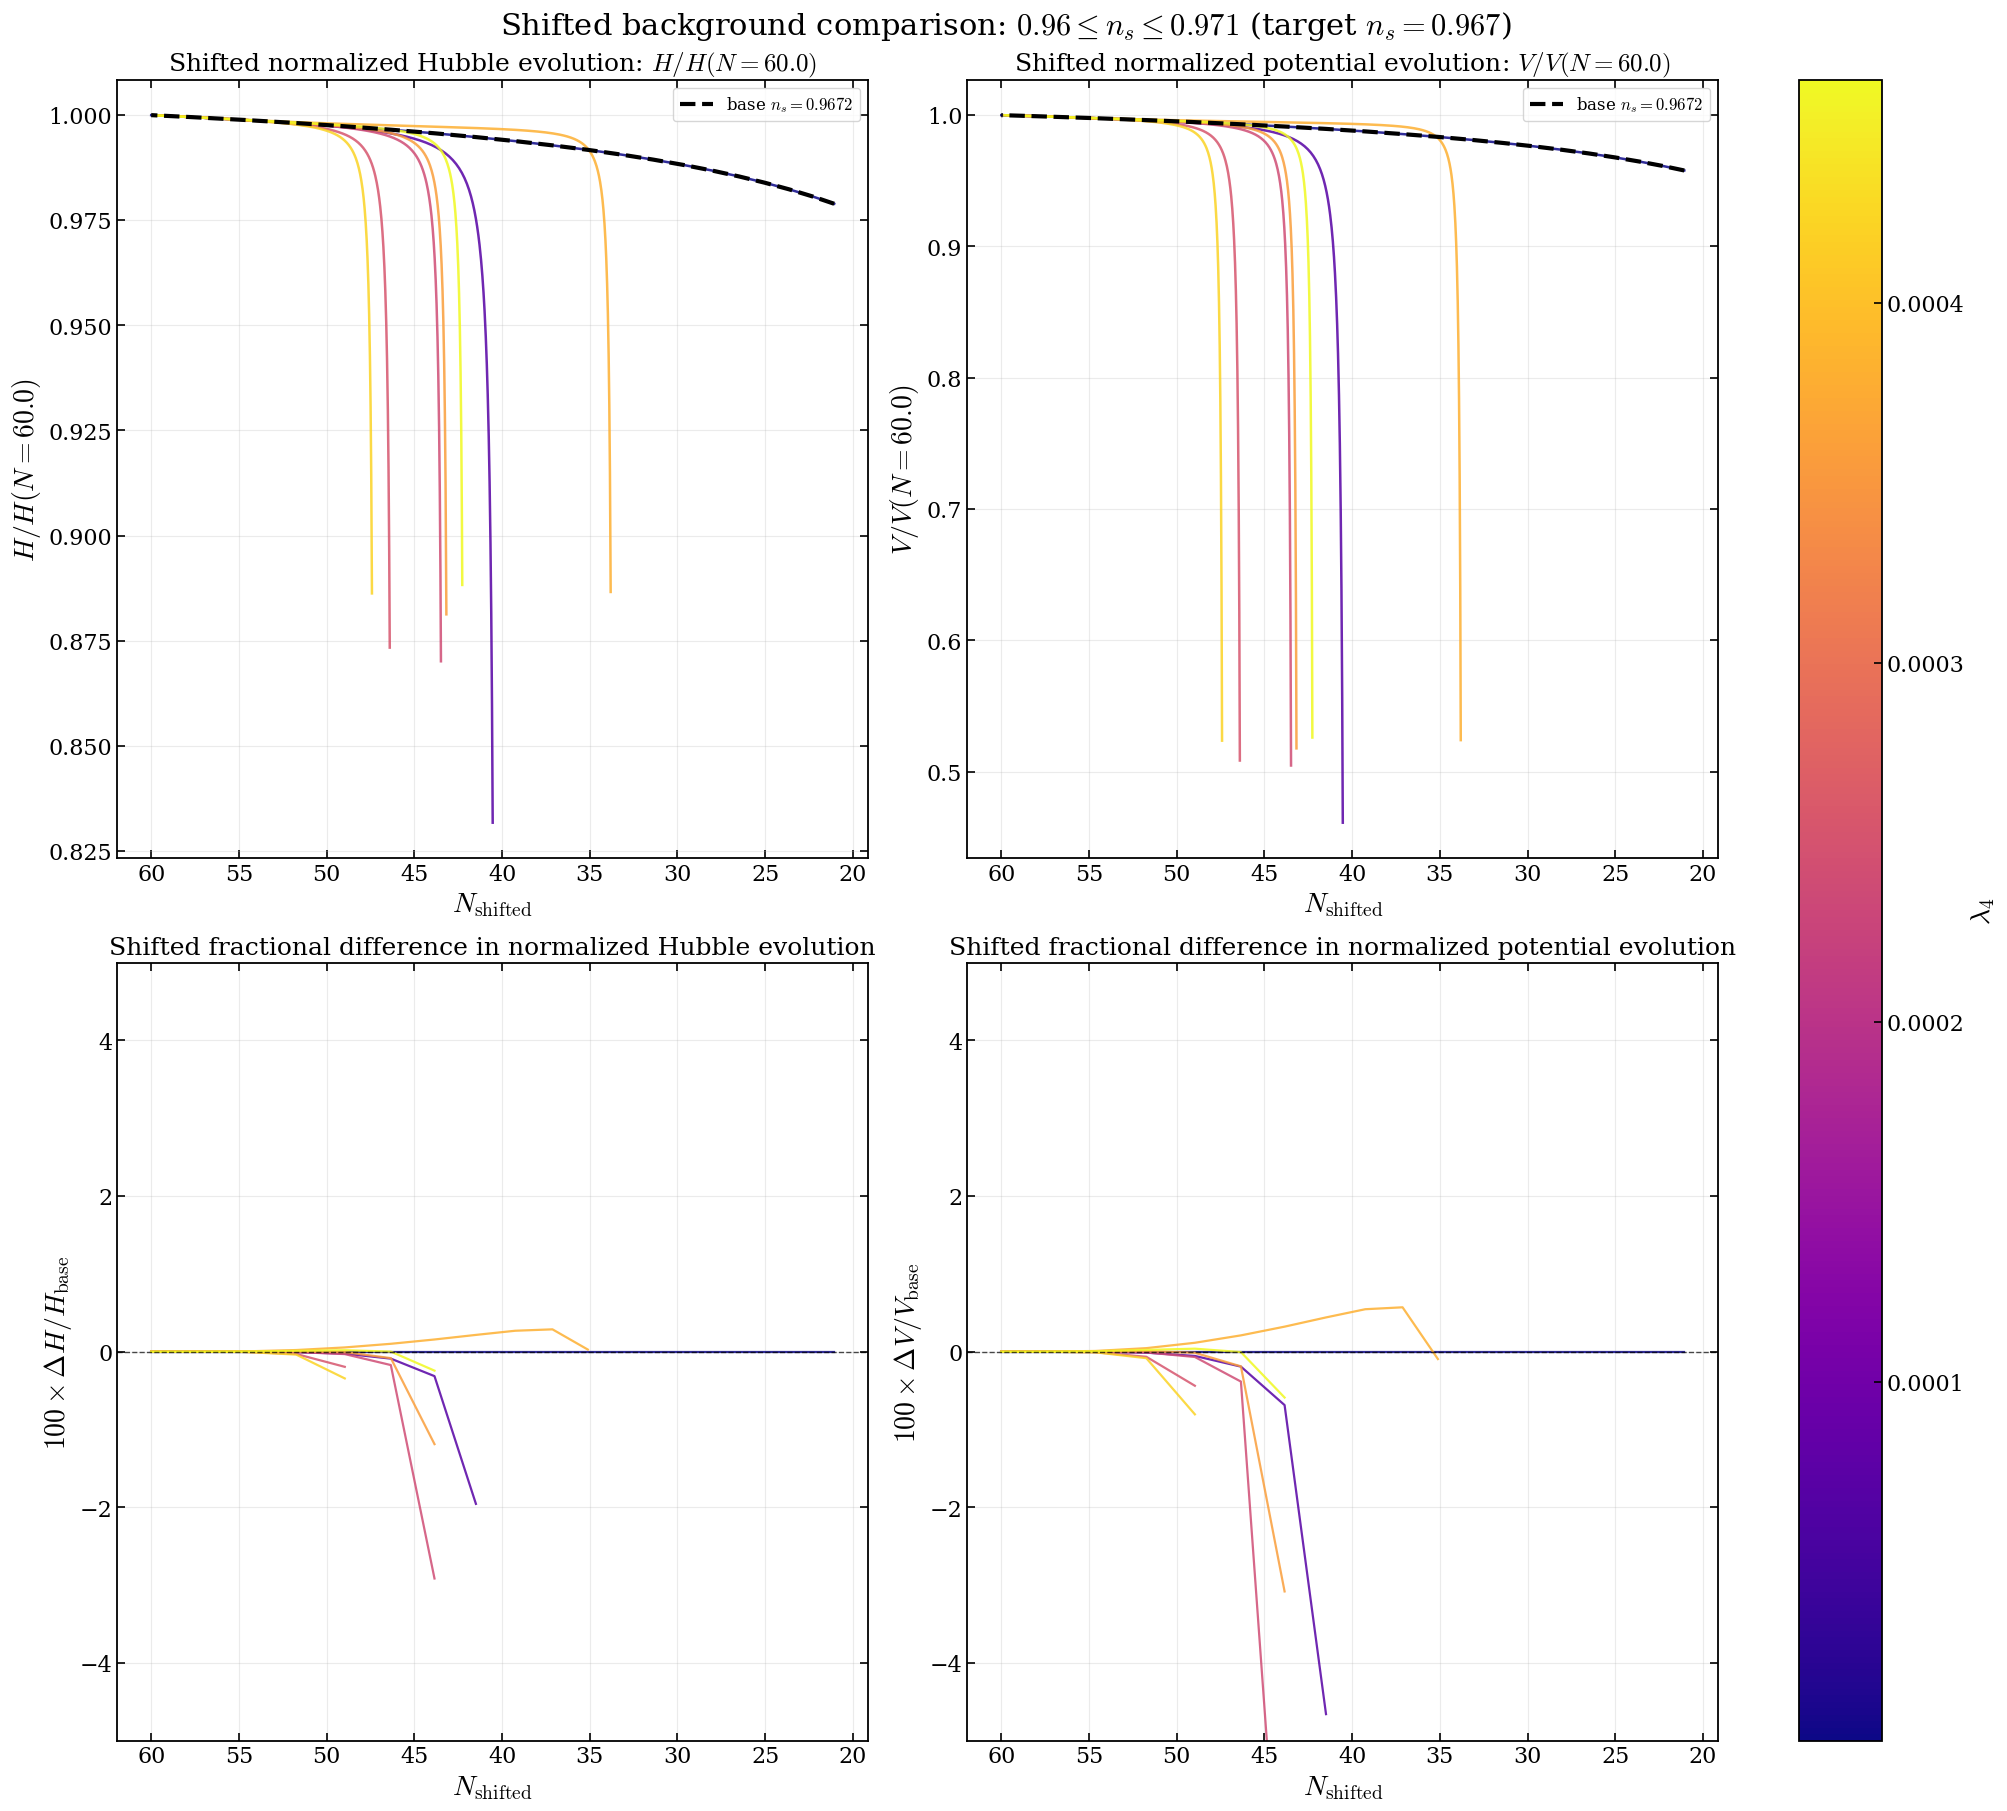

In [190]:
bg7_shifted_df = plot_shifted_background_by_ns(
    NEQS=7,
    lamX_values=lam4_values,
    baseX=6.87065e-08,
    base_path_root=base_path_root,
    ns_min=0.96,
    ns_max=0.971,
    N_ref=60.0,
    N_window=(20, 60),
    frac_ylim=(-5, 5),
    save_name="neqs7_lam4_shifted_background_publishable.png",
)

## Diagnostic Plots to Illustrate Difference After Applying N-shift

If I want to just look at the $\Delta$N for all my models I can do:

In [155]:
def plot_deltaN_histograms_neqs7_neqs8(
    base_path_root,
    base7_value=6.87065e-8,
    base8_value=-8.92461e-9,
    ns_min=None,
    ns_max=None,
    bins=30,
    save_name=None,
    show=True,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 13,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    configs = [
        {
            "NEQS": 7,
            "param": "lam4",
            "base_value": base7_value,
            "label": r"NEQS=7, $\lambda_4$ scan",
            "color": "plum",
        },
        {
            "NEQS": 8,
            "param": "lam5",
            "base_value": base8_value,
            "label": r"NEQS=8, $\lambda_5$ scan",
            "color": "mediumslateblue",
        },
    ]

    dfs = {}

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 6.5),
        constrained_layout=True,
        sharey=False,
    )

    for ax, cfg in zip(axes, configs):
        NEQS = cfg["NEQS"]
        param = cfg["param"]

        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        df = pd.read_csv(summary_file)

        base_row = df.loc[np.isclose(df[param], cfg["base_value"])]

        if len(base_row) == 0:
            raise ValueError(
                f"Could not find base {param}={cfg['base_value']:.10e} "
                f"in {summary_file}"
            )

        base_N_end = float(base_row.iloc[0]["original_N_end"])

        df["deltaN_from_base"] = df["original_N_end"] - base_N_end
        df["abs_deltaN_from_base"] = np.abs(df["deltaN_from_base"])

        if ns_min is not None:
            df = df[df["n_s"] >= ns_min].copy()

        if ns_max is not None:
            df = df[df["n_s"] <= ns_max].copy()

        dfs[f"neqs{NEQS}"] = df

        ax.hist(
            df["deltaN_from_base"],
            bins=bins,
            color=cfg["color"],
            alpha=0.75,
            edgecolor="black",
            linewidth=0.8,
        )

        ax.axvline(
            0.0,
            color="black",
            ls="--",
            lw=1.5,
            label="base model",
        )

        ax.set_title(cfg["label"])
        ax.set_xlabel(r"$\Delta N_{\rm end}=N_{\rm end}-N_{\rm end,base}$")
        ax.set_ylabel("number of models")

        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False)

        print("\n" + "=" * 70)
        print(cfg["label"])
        print("=" * 70)
        print(f"N models shown: {len(df)}")
        print(f"base original_N_end = {base_N_end:.6f}")
        print(df["deltaN_from_base"].describe().to_string())
        print("\nLargest |deltaN| models:")
        print(
            df[[param, "n_s", "original_N_end", "deltaN_from_base", "abs_deltaN_from_base"]]
            .sort_values("abs_deltaN_from_base", ascending=False)
            .head(15)
            .to_string(index=False)
        )

    title = r"Distribution of end-of-inflation offsets"

    if ns_min is not None or ns_max is not None:
        title += rf" for selected $n_s$ models"
    else:
        title += r" for all models"

    fig.suptitle(title, fontsize=22)

    if save_name is None:
        save_name = "deltaN_histograms_neqs7_neqs8.png"

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return dfs

If I run for all models I see:


NEQS=7, $\lambda_4$ scan
N models shown: 20
base original_N_end = 941.837071
count     20.000000
mean     -55.182017
std       94.227749
min     -175.295270
25%     -154.605457
50%       -2.712039
75%       40.965429
max       47.415242

Largest |deltaN| models:
     lam4      n_s  original_N_end  deltaN_from_base  abs_deltaN_from_base
 0.000111 0.961454      766.541801       -175.295270            175.295270
 0.000084 0.961164      777.707873       -164.129197            164.129197
 0.000007 0.961281      782.113041       -159.724029            159.724029
 0.000054 0.961140      783.136396       -158.700674            158.700674
 0.000401 0.961826      783.768391       -158.068680            158.068680
 0.000409 0.962778      788.386021       -153.451049            153.451049
-0.000146 0.961134      790.755531       -151.081539            151.081539
 0.000052 0.967465      800.691817       -141.145254            141.145254
 0.000054 0.968845      810.667473       -131.169598         

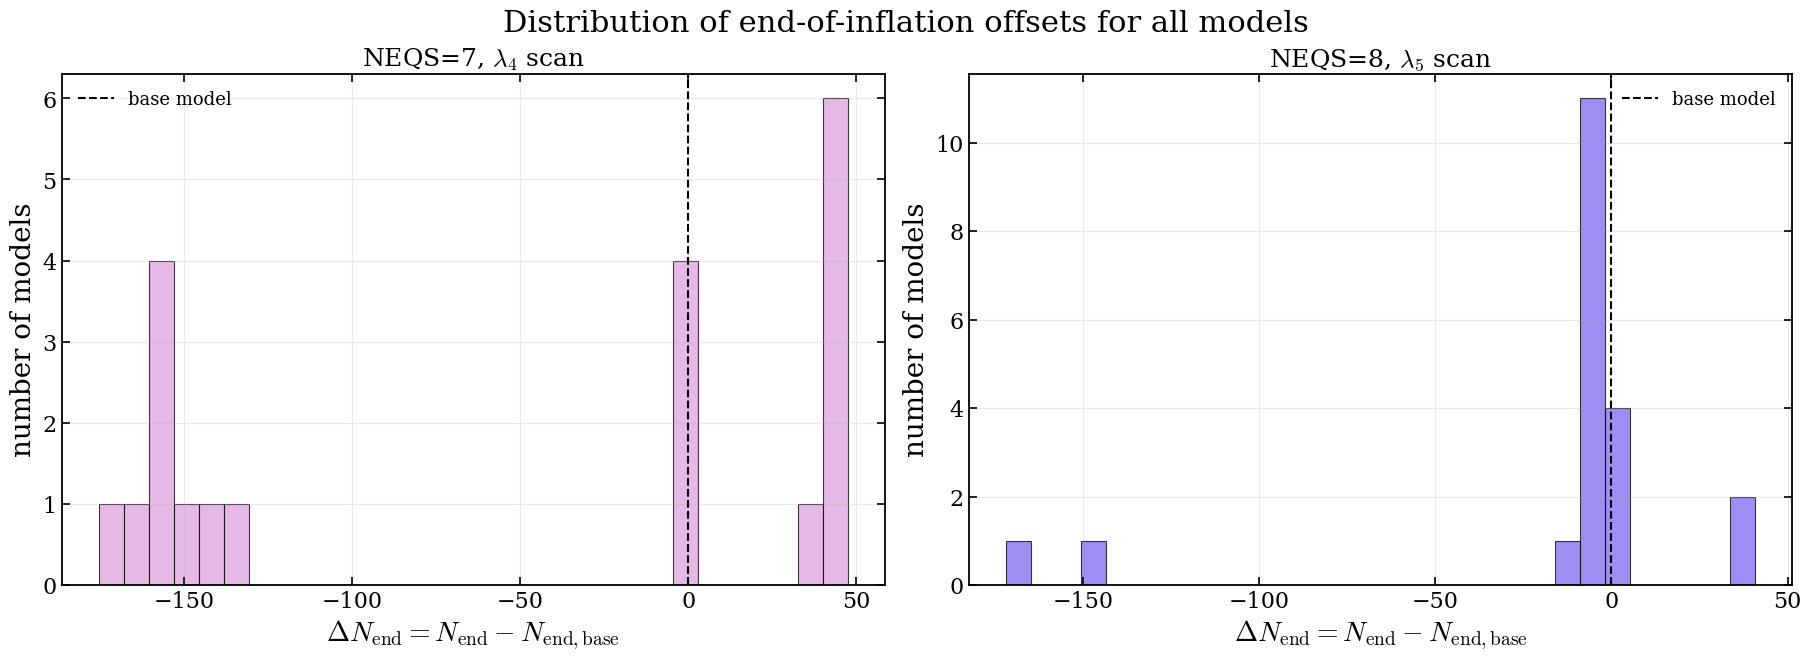

In [156]:
deltaN_dfs = plot_deltaN_histograms_neqs7_neqs8(
    base_path_root=base_path_root,
    bins=30,
    save_name="deltaN_histograms_neqs7_neqs8_all.png",
)

In [ ]:
# #If I was to run for models in a very specific ns range:

# deltaN_dfs_valid = plot_deltaN_histograms_neqs7_neqs8(
#     base_path_root=base_path_root,
#     ns_min=0.963,
#     ns_max=0.9699,
#     bins=20,
#     save_name="deltaN_histograms_neqs7_neqs8_valid_ns.png",
# )

This points to the fact that, yes, we can generate a massive number of models in this case we only wanted to generate models that will actually have a reasonable enough $\Delta$$N$ to still be consistent with what we are doing. If $\Delta$$N$ is too large, the model's shifted k is no longer in the k-range we are interested in looking at. Shifting it by it's $\Delta$$N$ if that is massive will not work. We make want to stick to a conservative $\Delta$$N$ range so no more than plus or minus 5 to start.

The plot below will show us which models have scalar and tensor power spectrum that pass our 5% threshold in error and allows us to toggle $\Delta$$N$.

In [159]:
def collect_shifted_errors_for_single_ref(
    base_path_root,
    lam_values,
    ref_NEQS,
    ref_param,
    ref_value,
    ns_min=0.963,
    ns_max=0.9699,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    max_abs_deltaN=None,
    skip_zero=True,
    zero_tol=1e-30,
):
    def folder_for(NEQS, param_name, value):
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{value:.10e}",
        )

    def load_specs(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def load_observables(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)
        arr = np.atleast_1d(
            np.loadtxt(os.path.join(folder, f"test_nr_neqs{NEQS}.dat"))
        )
        return arr[0], arr[1], arr[2]

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)
        matches = summary_df.loc[np.isclose(summary_df[param_name], value)]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(k_ref_grid, P_ref_norm, k_cmp, P_cmp_norm, kmin=None, kmax=None):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        if xmin >= xmax:
            return np.array([]), np.array([])

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)

        k_use = k_ref_grid[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use

        return k_use, frac

    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(k_s_ref_raw, Ps_ref_raw, k_norm)
    k_t_ref, Pt_ref_norm = normalize_at_k(k_t_ref_raw, Pt_ref_raw, k_norm)

    rows = []

    n_skipped_deltaN = 0
    n_skipped_ns = 0
    n_skipped_other = 0

    for item in lam_values:
        value = item[0] if isinstance(item, tuple) else item
        value = float(value)

        if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
            continue

        try:
            r, ns, alpha_s = load_observables(ref_NEQS, ref_param, value)

            if not (ns_min <= ns <= ns_max):
                n_skipped_ns += 1
                continue

            model_N_end = get_original_N_end(ref_NEQS, ref_param, value)
            deltaN = model_N_end - ref_N_end
            abs_deltaN = np.abs(deltaN)

            if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                n_skipped_deltaN += 1
                continue

            k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
                ref_NEQS,
                ref_param,
                value,
            )

            k_s_shifted = k_s_raw * np.exp(-deltaN)
            k_t_shifted = k_t_raw * np.exp(-deltaN)

            k_s_sh, Ps_sh = normalize_at_k(k_s_shifted, Ps_raw, k_norm)
            k_t_sh, Pt_sh = normalize_at_k(k_t_shifted, Pt_raw, k_norm)

            k_ps, frac_ps = frac_on_ref_grid(
                k_s_ref,
                Ps_ref_norm,
                k_s_sh,
                Ps_sh,
                kmin=k_min_scalar,
                kmax=k_max_scalar,
            )

            k_pt, frac_pt = frac_on_ref_grid(
                k_t_ref,
                Pt_ref_norm,
                k_t_sh,
                Pt_sh,
                kmin=None,
                kmax=None,
            )

            if len(frac_ps) == 0 or len(frac_pt) == 0:
                n_skipped_other += 1
                continue

            rows.append({
                "NEQS": ref_NEQS,
                "param_name": ref_param,
                "value": value,
                "r": r,
                "n_s": ns,
                "alpha_s": alpha_s,
                "original_N_end": model_N_end,
                "deltaN_from_ref_base": deltaN,
                "abs_deltaN": abs_deltaN,

                "k_min_scalar": k_min_scalar,
                "k_max_scalar": k_max_scalar,
                "max_abs_deltaN_cut": max_abs_deltaN,

                "mean_dPs_pct": 100.0 * np.nanmean(np.abs(frac_ps)),
                "max_dPs_pct": 100.0 * np.nanmax(np.abs(frac_ps)),
                "mean_dPt_pct": 100.0 * np.nanmean(np.abs(frac_pt)),
                "max_dPt_pct": 100.0 * np.nanmax(np.abs(frac_pt)),
            })

        except Exception as e:
            n_skipped_other += 1
            print(f"Skipping NEQS={ref_NEQS}, {ref_param}={value:.5e}: {e}")

    out_df = pd.DataFrame(rows)

    print("\n=== Collection summary ===")
    print(f"NEQS = {ref_NEQS}")
    print(f"Reference {ref_param} = {ref_value:.10e}")
    print(f"ns window = [{ns_min}, {ns_max}]")
    print(f"scalar k window = [{k_min_scalar}, {k_max_scalar}]")
    print(f"max |deltaN| cut = {max_abs_deltaN}")
    print(f"kept models = {len(out_df)}")
    print(f"skipped by ns = {n_skipped_ns}")
    print(f"skipped by |deltaN| = {n_skipped_deltaN}")
    print(f"skipped other = {n_skipped_other}")

    return out_df

In [185]:
def plot_scalar_tensor_max_error_vs_deltaN_single_ref(
    model_df,
    tolerance=5.0,
    deltaN_threshold=None,
    title_label=None,
    save_name=None,
    show=True,
):
    df = model_df.copy()

    df["scalar_passes"] = df["max_dPs_pct"] <= tolerance
    df["tensor_passes"] = df["max_dPt_pct"] <= tolerance

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)

    panels = [
        (
            axes[0],
            "max_dPs_pct",
            "scalar_passes",
            r"Scalar spectrum",
            r"$\max |\Delta P_s/P_{s,\rm base}| \;(\%)$",
        ),
        (
            axes[1],
            "max_dPt_pct",
            "tensor_passes",
            r"Tensor spectrum",
            r"$\max |\Delta P_t/P_{t,\rm base}| \;(\%)$",
        ),
    ]

    for ax, ycol, passcol, title, ylabel in panels:
        pass_df = df[df[passcol]]
        fail_df = df[~df[passcol]]

        ymin = max(1e-4, 0.5 * np.nanmin(df[ycol]))
        ymax = 2.0 * np.nanmax(df[ycol])
        xmax = 1.05 * np.nanmax(df["abs_deltaN"])

        ax.axhspan(ymin, tolerance, color="forestgreen", alpha=0.08)
        ax.axhspan(tolerance, ymax, color="crimson", alpha=0.04)

        ax.axhline(tolerance, color="black", lw=2.0, ls="--")

        ax.text(
            0.97 * xmax,
            tolerance * 1.08,
            rf"{tolerance:.0f}% tolerance",
            ha="right",
            va="bottom",
            fontsize=13,
        )

        ax.scatter(
            pass_df["abs_deltaN"],
            pass_df[ycol],
            s=120,
            color="forestgreen",
            edgecolor="black",
            linewidth=0.7,
            alpha=0.9,
            zorder=3,
        )

        ax.scatter(
            fail_df["abs_deltaN"],
            fail_df[ycol],
            s=220,
            marker="X",
            color="crimson",
            edgecolor="black",
            linewidth=1.0,
            alpha=0.95,
            zorder=4,
        )

        if deltaN_threshold is not None:
            ax.axvline(deltaN_threshold, color="navy", lw=2.0, ls=":")

            ax.text(
                deltaN_threshold,
                ymax / 2,
                rf"$|\Delta N|={deltaN_threshold:.2f}$",
                rotation=90,
                va="center",
                ha="left",
                fontsize=12,
                color="navy",
            )

        summary_text = f"Pass: {len(pass_df)}\nFail: {len(fail_df)}"

        ax.text(
            0.97,
            0.97,
            summary_text,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=12,
            bbox=dict(
                boxstyle="round",
                facecolor="white",
                edgecolor="gray",
                alpha=0.9,
            ),
        )

        ax.set_xlabel(r"$|\Delta N_{\rm end}|$")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.set_yscale("log")
        ax.set_ylim(ymin, ymax)
        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)

    if title_label is None:
        title_label = rf"NEQS={int(df['NEQS'].iloc[0])}"

    max_cut = df["max_abs_deltaN_cut"].iloc[0] if "max_abs_deltaN_cut" in df.columns else None

    if max_cut is not None and np.isfinite(max_cut):
        cut_text = rf", $|\Delta N_{{\rm end}}|\leq {max_cut}$"
    else:
        cut_text = ""

    fig.suptitle(
        rf"{title_label}: shifted spectral errors{cut_text}",
        fontsize=22,
    )

    if save_name is not None:
        plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    print("\n=== Error summary ===")
    print(f"Tolerance = {tolerance:.2f}%")
    print(f"Scalar pass = {df['scalar_passes'].sum()}")
    print(f"Scalar fail = {(~df['scalar_passes']).sum()}")
    print(f"Tensor pass = {df['tensor_passes'].sum()}")
    print(f"Tensor fail = {(~df['tensor_passes']).sum()}")

    return df

Now, with this cut lets see what we have:


=== Collection summary ===
NEQS = 7
Reference lam4 = 6.8706500000e-08
ns window = [0.96, 0.971]
scalar k window = [0.0001, 0.1]
max |deltaN| cut = 20.0
kept models = 4
skipped by ns = 0
skipped by |deltaN| = 16
skipped other = 0


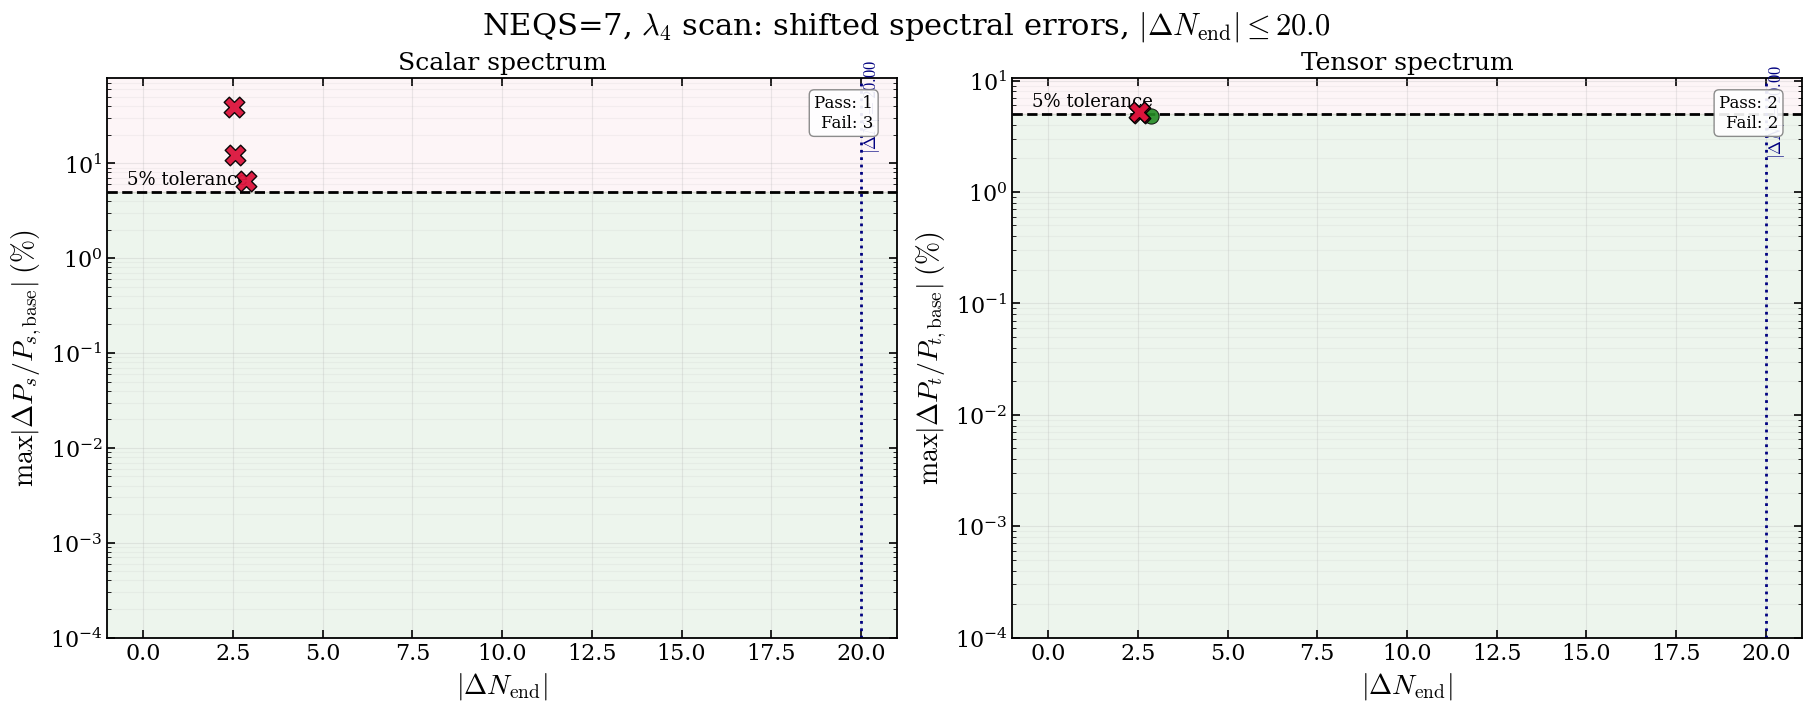


=== Error summary ===
Tolerance = 5.00%
Scalar pass = 1
Scalar fail = 3
Tensor pass = 2
Tensor fail = 2


In [186]:
neqs7_error_df = collect_shifted_errors_for_single_ref(
    base_path_root=base_path_root,
    lam_values=lam4_values,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    ns_min=0.96,
    ns_max=0.971,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    max_abs_deltaN=20.0,
)

neqs7_plot_df = plot_scalar_tensor_max_error_vs_deltaN_single_ref(
    neqs7_error_df,
    tolerance=5.0,
    deltaN_threshold=20.0,
    title_label=r"NEQS=7, $\lambda_4$ scan",
    save_name="neqs7_scalar_tensor_max_error_vs_deltaN_dN10.png",
)

Skipping NEQS=8, lam5=-2.15908e-05: k_ref=0.05 outside range [1.241e-01, 1.031e+19]

=== Collection summary ===
NEQS = 8
Reference lam5 = -8.9246100000e-09
ns window = [0.96, 0.971]
scalar k window = [0.0001, 0.1]
max |deltaN| cut = 20.0
kept models = 15
skipped by ns = 0
skipped by |deltaN| = 4
skipped other = 1


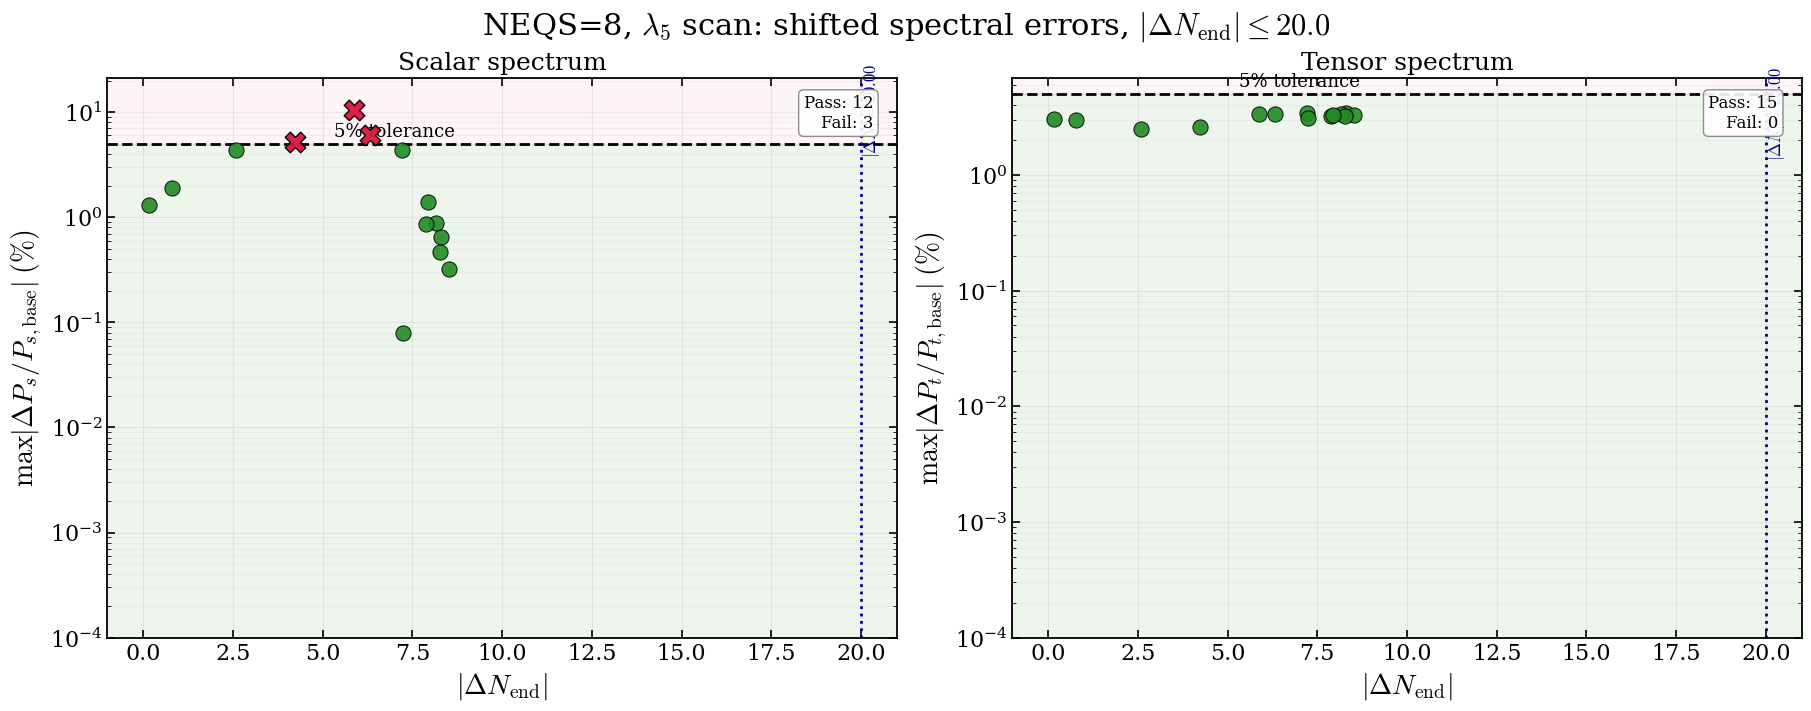


=== Error summary ===
Tolerance = 5.00%
Scalar pass = 12
Scalar fail = 3
Tensor pass = 15
Tensor fail = 0


In [187]:
neqs8_error_df = collect_shifted_errors_for_single_ref(
    base_path_root=base_path_root,
    lam_values=lam5_values,
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=-8.92461e-9,
    ns_min=0.96,
    ns_max=0.971,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    max_abs_deltaN=20.0,
)

neqs8_plot_df = plot_scalar_tensor_max_error_vs_deltaN_single_ref(
    neqs8_error_df,
    tolerance=5.0,
    deltaN_threshold=20.0,
    title_label=r"NEQS=8, $\lambda_5$ scan",
    save_name="neqs8_scalar_tensor_max_error_vs_deltaN_dN10.png",
)

Of the models that do not pass let's examine their structure:

In [201]:
def plot_failed_backgrounds_against_base(
    model_df,
    base_path_root,
    ref_NEQS,
    ref_param,
    ref_value,
    fail_on="scalar",
    tolerance=5.0,
    N_ref=60.0,
    N_window=(20, 60),
    shifted_N=True,
    normalize_before_shift=True,
    cmap_name="plasma",
    frac_ylim=None,
    eps_frac_ylim=None,
    save_name=None,
    show=True,
):
    scan_name = ref_param
    scan_symbol = SCAN_INFO[ref_NEQS][1]

    def folder_for(value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{ref_NEQS}",
            f"{scan_name}_{val_str}",
        )

    def load_path(value):
        val_str = f"{value:.10e}"
        f = os.path.join(
            folder_for(value),
            f"path_neqs{ref_NEQS}_{scan_name}_{val_str}.dat",
        )
        return pd.read_csv(f, sep=r"\s+", header=None).values

    def prepare_increasing(x, y):
        x = np.asarray(x)
        y = np.asarray(y)
        order = np.argsort(x)
        return x[order], y[order]

    def normalize_at_ref(N, Y, N_ref):
        N_use, Y_use = prepare_increasing(N, Y)

        if not (np.min(N_use) <= N_ref <= np.max(N_use)):
            raise ValueError(
                f"N_ref={N_ref} outside range [{np.min(N_use)}, {np.max(N_use)}]"
            )

        Y_ref = np.interp(N_ref, N_use, Y_use)

        if np.abs(Y_ref) < 1e-30:
            raise ValueError(f"Reference value too small at N_ref={N_ref}")

        return N_use, Y_use / Y_ref, Y_ref

    def apply_N_window(N, Y):
        if N_window is None:
            return N, Y

        Nmin, Nmax = N_window
        mask = (N >= Nmin) & (N <= Nmax)
        return N[mask], Y[mask]

    def frac_on_base_grid(N_base, Y_base, N_model, Y_model):
        N_base, Y_base = prepare_increasing(N_base, Y_base)
        N_model, Y_model = prepare_increasing(N_model, Y_model)

        Nmin = max(np.min(N_base), np.min(N_model))
        Nmax = min(np.max(N_base), np.max(N_model))

        if N_window is not None:
            Nmin = max(Nmin, N_window[0])
            Nmax = min(Nmax, N_window[1])

        mask = (N_base >= Nmin) & (N_base <= Nmax)

        N_use = N_base[mask]
        Y_base_use = Y_base[mask]

        if len(N_use) == 0:
            raise ValueError("No overlapping N range.")

        Y_model_interp = np.interp(N_use, N_model, Y_model)
        frac = (Y_model_interp - Y_base_use) / Y_base_use

        return N_use, frac

    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 20,
        "axes.titlesize": 18,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "legend.fontsize": 12,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    df = model_df.copy()

    scalar_fail = df["max_dPs_pct"] > tolerance
    tensor_fail = df["max_dPt_pct"] > tolerance

    if fail_on == "scalar":
        failed_df = df[scalar_fail].copy()
    elif fail_on == "tensor":
        failed_df = df[tensor_fail].copy()
    elif fail_on == "either":
        failed_df = df[scalar_fail | tensor_fail].copy()
    else:
        raise ValueError("fail_on must be 'scalar', 'tensor', or 'either'")

    print(f"\nModels failing {fail_on} criterion: {len(failed_df)}")

    if failed_df.empty:
        print("No failed models to plot. Tiny victory goblin.")
        return failed_df

    base_data = load_path(ref_value)

    H_base = base_data[:, 1]
    eps_base = base_data[:, 2]
    N_base = base_data[:, ref_NEQS]
    V_base = base_data[:, ref_NEQS + 1]

    N_base_H, H_base_norm, _ = normalize_at_ref(N_base, H_base, N_ref)
    N_base_V, V_base_norm, _ = normalize_at_ref(N_base, V_base, N_ref)
    N_base_eps, eps_base_norm, _ = normalize_at_ref(N_base, eps_base, N_ref)

    N_base_H_plot, H_base_plot = apply_N_window(N_base_H, H_base_norm)
    N_base_V_plot, V_base_plot = apply_N_window(N_base_V, V_base_norm)
    N_base_eps_plot, eps_base_plot = apply_N_window(N_base_eps, eps_base_norm)

    fig, axes = plt.subplots(
        3,
        2,
        figsize=(18, 16),
        constrained_layout=True,
    )

    ax_H, ax_V = axes[0]
    ax_dH, ax_dV = axes[1]
    ax_eps, ax_deps = axes[2]

    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.Normalize(
        vmin=failed_df["abs_deltaN"].min(),
        vmax=failed_df["abs_deltaN"].max(),
    )

    for _, row in failed_df.iterrows():
        value = row["value"]
        deltaN = row["deltaN_from_ref_base"]

        data = load_path(value)

        H = data[:, 1]
        eps = data[:, 2]
        N = data[:, ref_NEQS]
        V = data[:, ref_NEQS + 1]

        if normalize_before_shift:
            N_H, H_norm, _ = normalize_at_ref(N, H, N_ref)
            N_V, V_norm, _ = normalize_at_ref(N, V, N_ref)
            N_eps, eps_norm, _ = normalize_at_ref(N, eps, N_ref)

            if shifted_N:
                N_H = N_H + deltaN
                N_V = N_V + deltaN
                N_eps = N_eps + deltaN

        else:
            N_for_norm = N + deltaN if shifted_N else N

            N_H, H_norm, _ = normalize_at_ref(N_for_norm, H, N_ref)
            N_V, V_norm, _ = normalize_at_ref(N_for_norm, V, N_ref)
            N_eps, eps_norm, _ = normalize_at_ref(N_for_norm, eps, N_ref)

        N_H_plot, H_plot = apply_N_window(N_H, H_norm)
        N_V_plot, V_plot = apply_N_window(N_V, V_norm)
        N_eps_plot, eps_plot = apply_N_window(N_eps, eps_norm)

        try:
            N_frac_H, frac_H = frac_on_base_grid(
                N_base_H, H_base_norm, N_H, H_norm
            )

            N_frac_V, frac_V = frac_on_base_grid(
                N_base_V, V_base_norm, N_V, V_norm
            )

            N_frac_eps, frac_eps = frac_on_base_grid(
                N_base_eps, eps_base_norm, N_eps, eps_norm
            )

        except ValueError as e:
            print(f"Skipping background comparison for {scan_name}={value:.5e}: {e}")
            continue

        color = cmap(norm(row["abs_deltaN"]))

        label = (
            rf"${scan_symbol}={value:.1e}$, "
            rf"$|\Delta N|={row['abs_deltaN']:.2f}$"
        )

        ax_H.plot(
            N_H_plot,
            H_plot,
            color=color,
            lw=1.8,
            alpha=0.85,
            label=label,
        )

        ax_V.plot(
            N_V_plot,
            V_plot,
            color=color,
            lw=1.8,
            alpha=0.85,
        )

        ax_eps.plot(
            N_eps_plot,
            eps_plot,
            color=color,
            lw=1.8,
            alpha=0.85,
        )

        ax_dH.plot(
            N_frac_H,
            100.0 * frac_H,
            color=color,
            lw=1.6,
            alpha=0.85,
        )

        ax_dV.plot(
            N_frac_V,
            100.0 * frac_V,
            color=color,
            lw=1.6,
            alpha=0.85,
        )

        ax_deps.plot(
            N_frac_eps,
            100.0 * frac_eps,
            color=color,
            lw=1.6,
            alpha=0.85,
        )

    # Base overlays
    ax_H.plot(
        N_base_H_plot,
        H_base_plot,
        color="black",
        lw=3.0,
        ls="--",
        label="base",
    )

    ax_V.plot(
        N_base_V_plot,
        V_base_plot,
        color="black",
        lw=3.0,
        ls="--",
        label="base",
    )

    ax_eps.plot(
        N_base_eps_plot,
        eps_base_plot,
        color="black",
        lw=3.0,
        ls="--",
        label="base",
    )

    for ax in [ax_dH, ax_dV, ax_deps]:
        ax.axhline(0.0, color="black", lw=1.2, ls="--", alpha=0.7)

    norm_text = "normalized before shift" if normalize_before_shift else "normalized after shift"

    ax_H.set_title(rf"Failed models: $H/H(N={N_ref})$")
    ax_V.set_title(rf"Failed models: $V/V(N={N_ref})$")
    ax_eps.set_title(rf"Failed models: $\epsilon/\epsilon(N={N_ref})$")

    ax_dH.set_title(r"Fractional difference in $H(N)$")
    ax_dV.set_title(r"Fractional difference in $V(N)$")
    ax_deps.set_title(r"Fractional difference in $\epsilon(N)$")

    x_label = r"$N_{\rm shifted}$" if shifted_N else r"$N$"

    for ax in axes.ravel():
        ax.set_xlabel(x_label)
        ax.invert_xaxis()
        ax.grid(True, alpha=0.25)

    ax_H.set_ylabel(rf"$H/H(N={N_ref})$")
    ax_V.set_ylabel(rf"$V/V(N={N_ref})$")
    ax_eps.set_ylabel(rf"$\epsilon/\epsilon(N={N_ref})$")

    ax_dH.set_ylabel(r"$100\times\Delta H/H_{\rm base}$")
    ax_dV.set_ylabel(r"$100\times\Delta V/V_{\rm base}$")
    ax_deps.set_ylabel(r"$100\times\Delta\epsilon/\epsilon_{\rm base}$")

    if frac_ylim is not None:
        ax_dH.set_ylim(frac_ylim)
        ax_dV.set_ylim(frac_ylim)

    if eps_frac_ylim is not None:
        ax_deps.set_ylim(eps_frac_ylim)

    ax_H.legend(
        frameon=False,
        fontsize=10,
        loc="best",
    )

    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=axes, pad=0.02, fraction=0.035)
    cbar.set_label(r"$|\Delta N_{\rm end}|$", fontsize=18)

    shift_text = "shifted" if shifted_N else "unshifted"

    fig.suptitle(
        rf"NEQS={ref_NEQS}: failed {fail_on} models "
        rf"({shift_text}, {norm_text})",
        fontsize=22,
    )

    if save_name is None:
        save_name = (
            f"neqs{ref_NEQS}_{scan_name}_failed_{fail_on}_"
            f"background_{shift_text}_with_epsilon.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return failed_df

It is likely that if their backgrounds are similar they fail because the first slow roll parameter is busted. Let's see that!

For failed scalar: NEQS=7


Models failing scalar criterion: 3


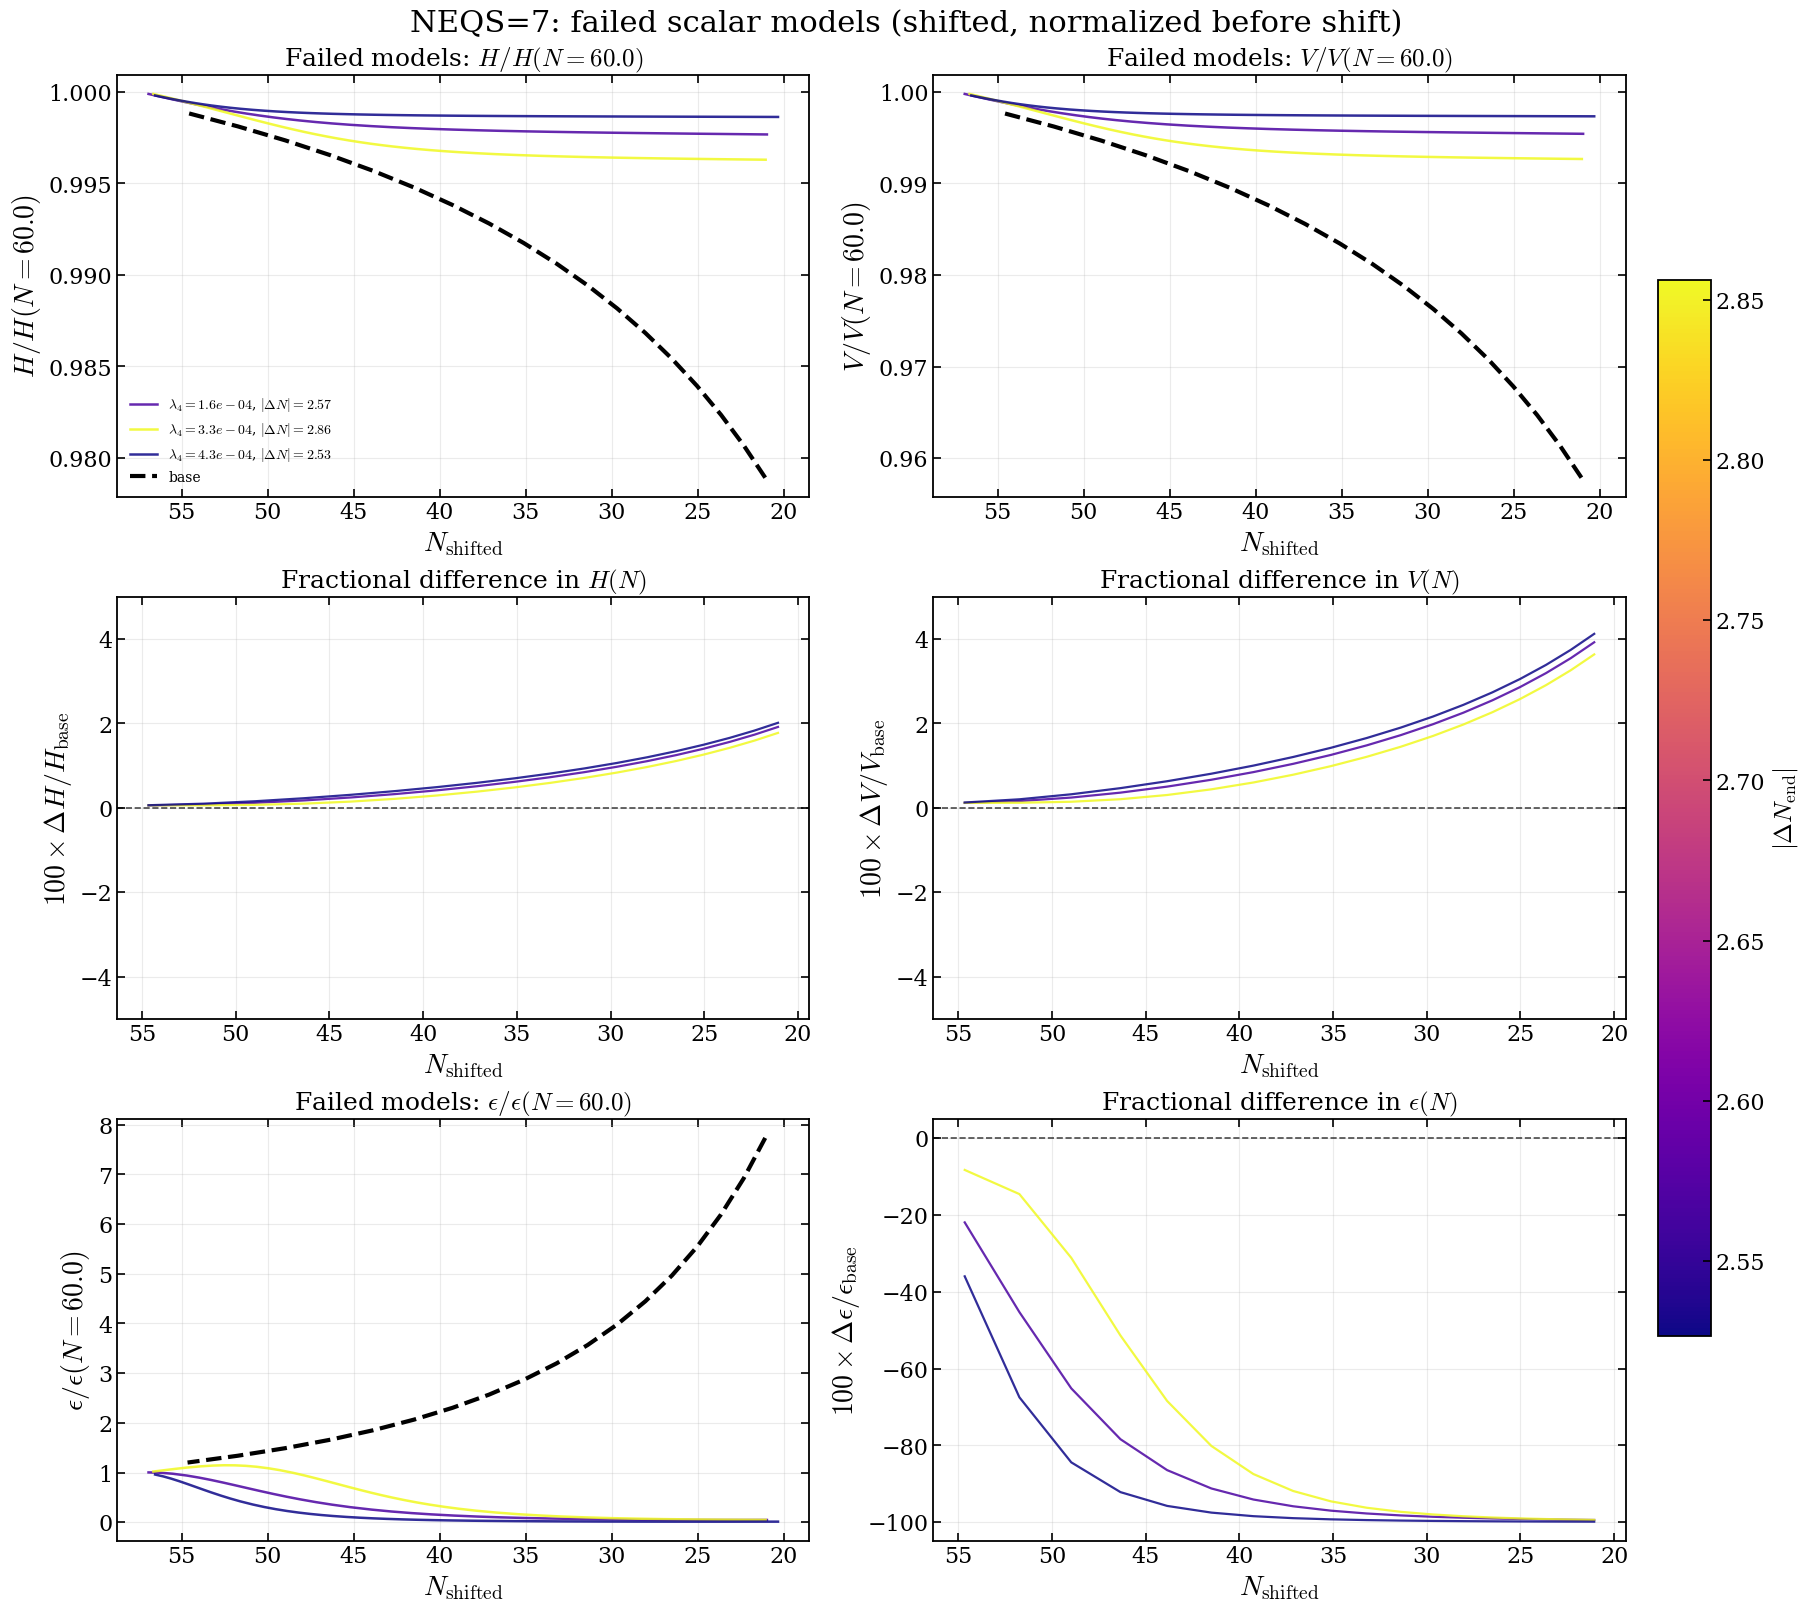

In [202]:
failed7_scalar_df = plot_failed_backgrounds_against_base(
    model_df=neqs7_plot_df,
    base_path_root=base_path_root,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    fail_on="scalar",
    tolerance=5.0,
    N_ref=60.0,
    N_window=(20, 57),
    shifted_N=True,
    frac_ylim=(-5, 5),
    save_name="neqs7_failed_scalar_backgrounds.png",
)

For failed scalar: NEQS=8


Models failing scalar criterion: 3


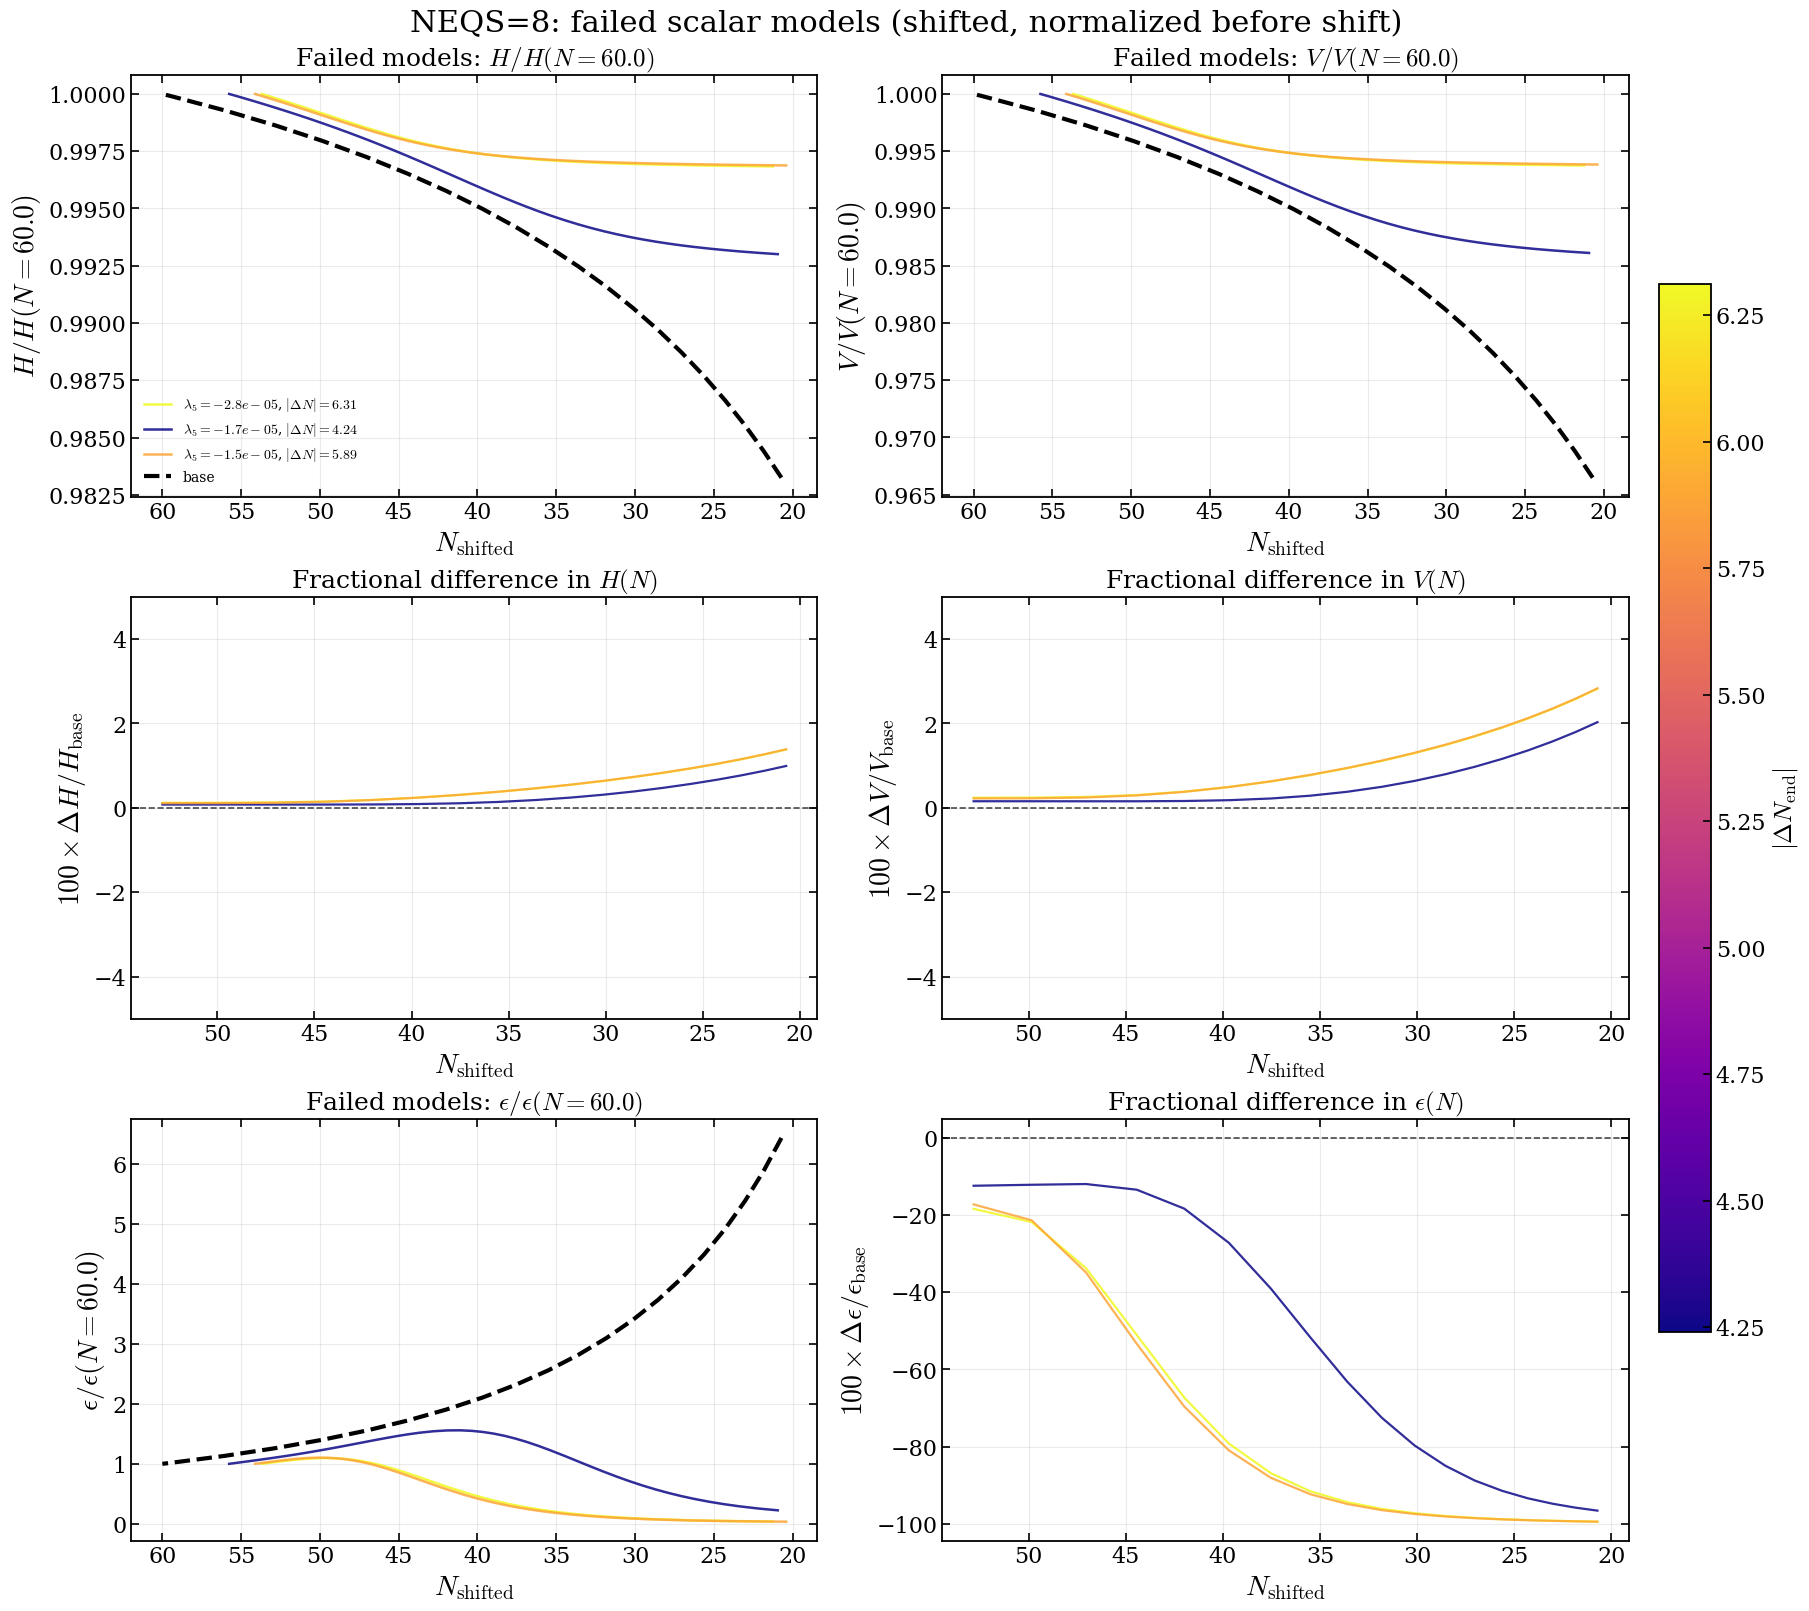

In [203]:
failed8_scalar_df = plot_failed_backgrounds_against_base(
    model_df=neqs8_plot_df,
    base_path_root=base_path_root,
    ref_NEQS=8,
    ref_param="lam5",
    ref_value=-8.92461e-9,
    fail_on="scalar",
    tolerance=5.0,
    N_ref=60.0,
    N_window=(20, 60),
    shifted_N=True,
    frac_ylim=(-5, 5),
    save_name="neqs8_failed_scalar_backgrounds.png",
)

Right, so now I want to look at the scalar and tensor power specta for models within a specific $\Delta$$N$ and ns range. I want to examine their mean and maxes to see what their error percentage is for models that pass.

In [199]:
def plot_valid_ns_before_after_kshift_envelopes(
    base_path_root,
    lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    ns_min=0.963,
    ns_max=0.970,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    max_abs_deltaN=None,
    tolerance=5.0,
    skip_zero=True,
    zero_tol=1e-30,
    save_name=None,
):
    plt.rcParams.update({
        "text.usetex": False,
        "mathtext.fontset": "cm",
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
        "axes.labelsize": 18,
        "axes.titlesize": 17,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 11,
        "figure.titlesize": 22,
        "axes.linewidth": 1.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    })

    colors_by_neqs = {
        7: "plum",
        8: "mediumslateblue",
    }

    def folder_for(NEQS, param_name, value):
        val_str = f"{value:.10e}"
        return os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"{param_name}_{val_str}",
        )

    def load_specs(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)

        s = np.loadtxt(os.path.join(folder, f"spec_s_neqs{NEQS}.dat"))
        t = np.loadtxt(os.path.join(folder, f"spec_t_neqs{NEQS}.dat"))

        k_s, Ps = prepare_increasing(s[:, 0], np.abs(s[:, 1]))
        k_t, Pt = prepare_increasing(t[:, 0], np.abs(t[:, 1]))

        return k_s, Ps, k_t, Pt

    def load_observables(NEQS, param_name, value):
        folder = folder_for(NEQS, param_name, value)
        arr = np.loadtxt(os.path.join(folder, f"test_nr_neqs{NEQS}.dat"))
        arr = np.atleast_1d(arr)
        return arr[0], arr[1], arr[2]

    def get_original_N_end(NEQS, param_name, value):
        summary_file = os.path.join(
            base_path_root,
            f"neqs{NEQS}",
            f"neqs{NEQS}_summary.csv",
        )

        summary_df = pd.read_csv(summary_file)
        matches = summary_df.loc[np.isclose(summary_df[param_name], value)]

        if len(matches) == 0:
            raise ValueError(
                f"No summary row found for NEQS={NEQS}, "
                f"{param_name}={value:.10e}"
            )

        return float(matches.iloc[0]["original_N_end"])

    def normalize_at_k(k, P, k_ref):
        k, P = prepare_increasing(k, P)

        if not (k.min() <= k_ref <= k.max()):
            raise ValueError(
                f"k_ref={k_ref} outside range [{k.min():.3e}, {k.max():.3e}]"
            )

        P_ref = np.interp(k_ref, k, P)

        if np.abs(P_ref) < 1e-30:
            raise ValueError(f"Reference spectrum too small at k={k_ref}")

        return k, P / P_ref

    def frac_on_ref_grid(
        k_ref_grid,
        P_ref_norm,
        k_cmp,
        P_cmp_norm,
        kmin=None,
        kmax=None,
    ):
        k_ref_grid, P_ref_norm = prepare_increasing(k_ref_grid, P_ref_norm)
        k_cmp, P_cmp_norm = prepare_increasing(k_cmp, P_cmp_norm)

        xmin = max(k_ref_grid.min(), k_cmp.min())
        xmax = min(k_ref_grid.max(), k_cmp.max())

        if kmin is not None:
            xmin = max(xmin, kmin)

        if kmax is not None:
            xmax = min(xmax, kmax)

        if xmin >= xmax:
            return np.array([]), np.array([])

        mask = (k_ref_grid >= xmin) & (k_ref_grid <= xmax)
        k_use = k_ref_grid[mask]

        if len(k_use) == 0:
            return np.array([]), np.array([])

        P_ref_use = P_ref_norm[mask]
        P_cmp_interp = np.interp(k_use, k_cmp, P_cmp_norm)

        frac = (P_cmp_interp - P_ref_use) / P_ref_use
        return k_use, frac

    def collect_envelope(frac_curves, k_ref_grid):
        if len(frac_curves) == 0:
            return None, None, None

        k_env = k_ref_grid.copy()
        frac_stack = []

        for k_curve, frac_curve in frac_curves:
            if len(k_curve) < 2:
                continue

            interp = np.interp(
                k_env,
                k_curve,
                frac_curve,
                left=np.nan,
                right=np.nan,
            )

            if np.all(~np.isfinite(interp)):
                continue

            frac_stack.append(interp)

        if len(frac_stack) == 0:
            return None, None, None

        frac_stack = np.array(frac_stack)

        valid_cols = np.any(np.isfinite(frac_stack), axis=0)
        frac_stack = frac_stack[:, valid_cols]
        k_env = k_env[valid_cols]

        abs_stack = np.abs(frac_stack)

        mean_abs = 100.0 * np.nanmean(abs_stack, axis=0)
        max_abs = 100.0 * np.nanmax(abs_stack, axis=0)

        return k_env, mean_abs, max_abs

    # Reference spectra
    ref_N_end = get_original_N_end(ref_NEQS, ref_param, ref_value)

    k_s_ref_raw, Ps_ref_raw, k_t_ref_raw, Pt_ref_raw = load_specs(
        ref_NEQS,
        ref_param,
        ref_value,
    )

    k_s_ref, Ps_ref_norm = normalize_at_k(k_s_ref_raw, Ps_ref_raw, k_norm)
    k_t_ref, Pt_ref_norm = normalize_at_k(k_t_ref_raw, Pt_ref_raw, k_norm)

    curves = {
        NEQS: {
            "Ps_unshift": [],
            "Ps_shift": [],
            "Pt_unshift": [],
            "Pt_shift": [],
            "rows": [],
            "skipped_deltaN": 0,
            "skipped_ns": 0,
            "skipped_other": 0,
        }
        for NEQS in lam_values_by_neqs.keys()
    }

    for NEQS, lam_values in lam_values_by_neqs.items():
        param_name, _ = SCAN_INFO[NEQS]

        for item in lam_values:
            value = item[0] if isinstance(item, tuple) else item
            value = float(value)

            if skip_zero and np.isclose(value, 0.0, atol=zero_tol):
                continue

            try:
                r, ns, alpha_s = load_observables(NEQS, param_name, value)

                if not (ns_min <= ns <= ns_max):
                    curves[NEQS]["skipped_ns"] += 1
                    continue

                model_N_end = get_original_N_end(NEQS, param_name, value)
                deltaN = model_N_end - ref_N_end
                abs_deltaN = np.abs(deltaN)

                if max_abs_deltaN is not None and abs_deltaN > max_abs_deltaN:
                    curves[NEQS]["skipped_deltaN"] += 1
                    continue

                k_s_raw, Ps_raw, k_t_raw, Pt_raw = load_specs(
                    NEQS,
                    param_name,
                    value,
                )

                # Unshifted comparison
                k_s_un, Ps_un = normalize_at_k(k_s_raw, Ps_raw, k_norm)
                k_t_un, Pt_un = normalize_at_k(k_t_raw, Pt_raw, k_norm)

                k_ps_un, frac_ps_un = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_un,
                    Ps_un,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_un, frac_pt_un = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_un,
                    Pt_un,
                )

                # Shifted comparison
                k_s_shifted = k_s_raw * np.exp(-deltaN)
                k_t_shifted = k_t_raw * np.exp(-deltaN)

                k_s_sh, Ps_sh = normalize_at_k(k_s_shifted, Ps_raw, k_norm)
                k_t_sh, Pt_sh = normalize_at_k(k_t_shifted, Pt_raw, k_norm)

                k_ps_sh, frac_ps_sh = frac_on_ref_grid(
                    k_s_ref,
                    Ps_ref_norm,
                    k_s_sh,
                    Ps_sh,
                    kmin=k_min_scalar,
                    kmax=k_max_scalar,
                )

                k_pt_sh, frac_pt_sh = frac_on_ref_grid(
                    k_t_ref,
                    Pt_ref_norm,
                    k_t_sh,
                    Pt_sh,
                )

                if (
                    len(frac_ps_un) == 0
                    or len(frac_ps_sh) == 0
                    or len(frac_pt_un) == 0
                    or len(frac_pt_sh) == 0
                ):
                    curves[NEQS]["skipped_other"] += 1
                    continue

                curves[NEQS]["Ps_unshift"].append((k_ps_un, frac_ps_un))
                curves[NEQS]["Ps_shift"].append((k_ps_sh, frac_ps_sh))
                curves[NEQS]["Pt_unshift"].append((k_pt_un, frac_pt_un))
                curves[NEQS]["Pt_shift"].append((k_pt_sh, frac_pt_sh))

                curves[NEQS]["rows"].append({
                    "NEQS": NEQS,
                    "param_name": param_name,
                    "value": value,
                    "r": r,
                    "ns": ns,
                    "alpha_s": alpha_s,
                    "original_N_end": model_N_end,
                    "deltaN_from_ref_base": deltaN,
                    "abs_deltaN_from_ref_base": abs_deltaN,
                    "k_min_scalar": k_min_scalar,
                    "k_max_scalar": k_max_scalar,
                    "max_abs_deltaN_cut": max_abs_deltaN,

                    "max_Ps_unshift_pct": 100.0 * np.nanmax(np.abs(frac_ps_un)),
                    "max_Ps_shift_pct": 100.0 * np.nanmax(np.abs(frac_ps_sh)),
                    "max_Pt_unshift_pct": 100.0 * np.nanmax(np.abs(frac_pt_un)),
                    "max_Pt_shift_pct": 100.0 * np.nanmax(np.abs(frac_pt_sh)),

                    "mean_Ps_unshift_pct": 100.0 * np.nanmean(np.abs(frac_ps_un)),
                    "mean_Ps_shift_pct": 100.0 * np.nanmean(np.abs(frac_ps_sh)),
                    "mean_Pt_unshift_pct": 100.0 * np.nanmean(np.abs(frac_pt_un)),
                    "mean_Pt_shift_pct": 100.0 * np.nanmean(np.abs(frac_pt_sh)),
                })

            except FileNotFoundError:
                print(f"Missing files for NEQS={NEQS}, {param_name}={value:.5e}")
                curves[NEQS]["skipped_other"] += 1

            except ValueError as e:
                print(f"Skipping NEQS={NEQS}, {param_name}={value:.5e}: {e}")
                curves[NEQS]["skipped_other"] += 1

    # Plot
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10.5),
        constrained_layout=True,
    )

    ax_ps_un, ax_ps_sh = axes[0]
    ax_pt_un, ax_pt_sh = axes[1]

    plot_specs = [
        ("Ps_unshift", ax_ps_un, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", "Before $k$-shift"),
        ("Ps_shift", ax_ps_sh, k_s_ref, k_min_scalar, k_max_scalar, r"$P_s$", r"After $k \to k e^{-\Delta N}$"),
        ("Pt_unshift", ax_pt_un, k_t_ref, None, None, r"$P_t$", "Before $k$-shift"),
        ("Pt_shift", ax_pt_sh, k_t_ref, None, None, r"$P_t$", r"After $k \to k e^{-\Delta N}$"),
    ]

    envelope_rows = []

    for key, ax, k_ref_grid, kmin, kmax, quantity_label, title_suffix in plot_specs:
        for NEQS in lam_values_by_neqs.keys():
            color = colors_by_neqs.get(NEQS, None)

            k_env, mean_abs, max_abs = collect_envelope(
                curves[NEQS][key],
                k_ref_grid,
            )

            if k_env is None:
                continue

            mask = np.ones_like(k_env, dtype=bool)

            if kmin is not None:
                mask &= k_env >= kmin

            if kmax is not None:
                mask &= k_env <= kmax

            k_env = k_env[mask]
            mean_abs = mean_abs[mask]
            max_abs = max_abs[mask]

            if len(k_env) == 0:
                continue

            ax.plot(
                k_env,
                mean_abs,
                color=color,
                lw=2.2,
                label=rf"NEQS={NEQS} mean",
            )

            ax.fill_between(
                k_env,
                0.0,
                max_abs,
                color=color,
                alpha=0.20,
                label=rf"NEQS={NEQS} max",
            )

            envelope_rows.append({
                "NEQS": NEQS,
                "case": key,
                "n_models": len(curves[NEQS][key]),
                "median_mean_abs_pct": np.nanmedian(mean_abs),
                "max_envelope_pct": np.nanmax(max_abs),
                "k_min_scalar": k_min_scalar if "Ps" in key else np.nan,
                "k_max_scalar": k_max_scalar if "Ps" in key else np.nan,
                "max_abs_deltaN_cut": max_abs_deltaN,
            })

        # 5% tolerance line
        ax.axhline(
            tolerance,
            color="black",
            lw=1.7,
            ls="--",
            label=rf"{tolerance:.0f}\% tolerance",
        )

        ax.text(
            0.97,
            0.92,
            rf"{tolerance:.0f}\% tolerance",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=11,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.80,
            ),
        )

        ax.set_xscale("log")
#         ax.set_yscale("log")

        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.12)
        ax.minorticks_on()

        ax.set_title(rf"{quantity_label} error envelope: {title_suffix}")
        ax.set_xlabel(r"$k$")
        ax.set_ylabel(rf"$|\Delta {quantity_label}/{quantity_label}|$ [\%]")

        if kmin is not None or kmax is not None:
            xmin = kmin if kmin is not None else k_ref_grid.min()
            xmax = kmax if kmax is not None else k_ref_grid.max()
            ax.set_xlim(xmin, xmax)

        ax.legend(
            fontsize=9,
            frameon=False,
            loc="best",
        )

    cut_text = ""

    if max_abs_deltaN is not None:
        cut_text += rf", $|\Delta N| \leq {max_abs_deltaN}$"

    if k_min_scalar is not None or k_max_scalar is not None:
        kmin_text = k_min_scalar if k_min_scalar is not None else k_s_ref.min()
        kmax_text = k_max_scalar if k_max_scalar is not None else k_s_ref.max()
        cut_text += rf", scalar $k\in[{kmin_text:.0e},{kmax_text:.0e}]$"

    fig.suptitle(
        rf"Valid-$n_s$ spectral-error envelopes relative to NEQS={ref_NEQS} base "
        rf"(${ns_min}<n_s<{ns_max}$){cut_text}",
        fontsize=20,
    )

    if save_name is None:
        save_name = (
            f"valid_ns_error_envelopes_before_after_shift_"
            f"ref_neqs{ref_NEQS}.png"
        )

    plt.savefig(save_name, dpi=300, bbox_inches="tight")
    plt.show()

    model_rows = []
    for NEQS in lam_values_by_neqs.keys():
        model_rows.extend(curves[NEQS]["rows"])

    model_df = pd.DataFrame(model_rows)
    envelope_df = pd.DataFrame(envelope_rows)

    print("\n=== Cut summary ===")
    for NEQS in lam_values_by_neqs.keys():
        print(
            f"NEQS={NEQS}: kept={len(curves[NEQS]['rows'])}, "
            f"skipped_ns={curves[NEQS]['skipped_ns']}, "
            f"skipped_deltaN={curves[NEQS]['skipped_deltaN']}, "
            f"skipped_other={curves[NEQS]['skipped_other']}"
        )

    print("\n=== Envelope summary ===")
    if not envelope_df.empty:
        print(envelope_df.to_string(index=False))

    print("\n=== Model-level summary ===")
    if not model_df.empty:
        print(model_df.to_string(index=False))

    return model_df, envelope_df

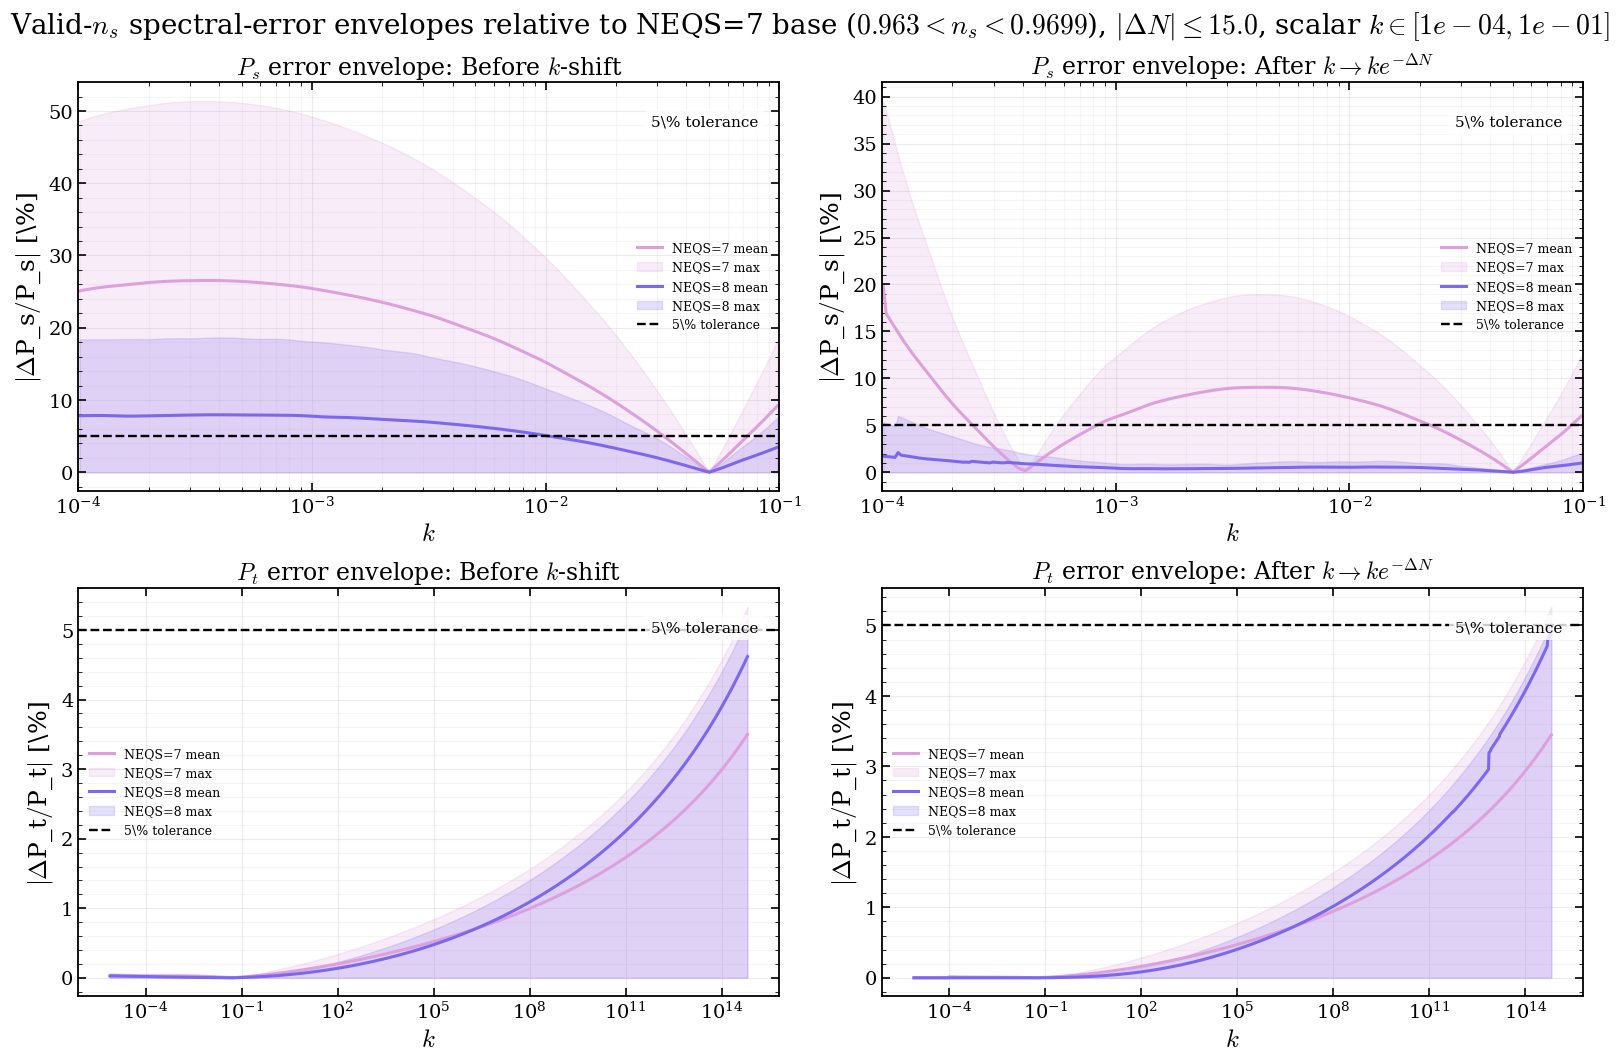


=== Cut summary ===
NEQS=7: kept=3, skipped_ns=9, skipped_deltaN=8, skipped_other=0
NEQS=8: kept=15, skipped_ns=3, skipped_deltaN=2, skipped_other=0

=== Envelope summary ===
 NEQS       case  n_models  median_mean_abs_pct  max_envelope_pct  k_min_scalar  k_max_scalar  max_abs_deltaN_cut
    7 Ps_unshift         3            21.792013         51.376442        0.0001           0.1                15.0
    8 Ps_unshift        15             6.955909         18.663188        0.0001           0.1                15.0
    7   Ps_shift         3             6.382075         39.533607        0.0001           0.1                15.0
    8   Ps_shift        15             0.532783          6.000925        0.0001           0.1                15.0
    7 Pt_unshift         3             0.500929          5.336882           NaN           NaN                15.0
    8 Pt_unshift        15             0.453312          5.164214           NaN           NaN                15.0
    7   Pt_shift         3

In [200]:
lam_values_by_neqs = {
    7: lam4_values,
    8: lam5_values,
}


model_df, envelope_df = plot_valid_ns_before_after_kshift_envelopes(
    base_path_root=base_path_root,
    lam_values_by_neqs=lam_values_by_neqs,
    ref_NEQS=7,
    ref_param="lam4",
    ref_value=6.87065e-8,
    ns_min=0.963,
    ns_max=0.9699,
    k_norm=0.05,
    k_min_scalar=1e-4,
    k_max_scalar=1e-1,
    max_abs_deltaN=15.0,
    skip_zero=True,
    save_name="valid_ns_before_after_kshift_envelopes_ref_neqs7_dN10_k1e-4_1e-1.png",
)